# Control vs SDV: latent-variable causal models
This notebook applies the existing Case 2 and Case 4 estimators to paired CONN 19-ROI BOLD time series. Outputs are descriptive; no biological causal claims or inferential tests are made.

## 1. Setup

In [ ]:
from pathlib import Path
import os, sys, numpy as np
from IPython.display import Image, display
ROOT=Path.cwd().parent if Path.cwd().name=='notebooks' else Path.cwd()
sys.path.insert(0,str(ROOT/'src'))
from causal_opt.fmri import *
from causal_opt.methods.static_latent import fit_static_latent
from causal_opt.methods.dynamic_latent import fit_dynamic_latent
DATA=ROOT.parent/'fmri_connectivity'/'data'/'mat_files'/'rs_sessions_r03_healthy'
SESSION1=Path(os.getenv('FMRI_SESSION1_ZIP',DATA/'roi_rs_sessions_Session1.zip'))
SESSION2=Path(os.getenv('FMRI_SESSION2_ZIP',DATA/'roi_rs_sessions_Session2.zip'))
OUTPUT=ROOT/'results'/'fmri_notebook'; OUTPUT.mkdir(parents=True,exist_ok=True)
SEED=1; K=2; P=1; EDGE_THRESHOLD=.3
MAX_OUTER=100; INNER_MAX=500;
STATIC=dict(k=K,lambda_w=.1,lambda_latent=.1,w_threshold=EDGE_THRESHOLD,random_state=SEED,max_outer_iter=MAX_OUTER,inner_max_iter=INNER_MAX)
DYNAMIC=dict(k=K,lambda_0=.1,lambda_lag=.05,lambda_latent=.02,w0_threshold=EDGE_THRESHOLD,wlag_threshold=EDGE_THRESHOLD,random_state=SEED,max_outer_iter=MAX_OUTER,inner_max_iter=INNER_MAX)
DISPLAY=tuple(f'BN19-{i:02d}' for i in range(1,20))
DISPLAY=BLADDER19_LABELS

## 2. Load 19-ROI fMRI data

In [3]:
control,sdv=load_fmri_state_data(SESSION1,SESSION2)
print(data_summary(control,'control / empty bladder'))
print(data_summary(sdv,'full bladder / SDV'))
print(control.subject_ids); print(control.roi_names)
X_control=build_static_fmri_matrix(control); X_sdv=build_static_fmri_matrix(sdv)
print('pooled:',X_control.shape,X_sdv.shape)

{'state': 'control / empty bladder', 'subjects': 19, 'rois': 19, 'T_min': 168, 'T_median': 192.0, 'T_max': 194, 'pooled_rows': 3627}
{'state': 'full bladder / SDV', 'subjects': 19, 'rois': 19, 'T_min': 168, 'T_median': 192.0, 'T_max': 196, 'pooled_rows': 3628}
('Subject001', 'Subject002', 'Subject003', 'Subject004', 'Subject005', 'Subject006', 'Subject007', 'Subject008', 'Subject009', 'Subject010', 'Subject011', 'Subject012', 'Subject013', 'Subject014', 'Subject015', 'Subject016', 'Subject017', 'Subject018', 'Subject019')
('Bladder Network 19.cluster001', 'Bladder Network 19.cluster002', 'Bladder Network 19.cluster003', 'Bladder Network 19.cluster004', 'Bladder Network 19.cluster005', 'Bladder Network 19.cluster006', 'Bladder Network 19.cluster007', 'Bladder Network 19.cluster008', 'Bladder Network 19.cluster009', 'Bladder Network 19.cluster010', 'Bladder Network 19.cluster011', 'Bladder Network 19.cluster012', 'Bladder Network 19.cluster013', 'Bladder Network 19.cluster014', 'Bladder 

## 3. Case 2 — static latent-confounded causal model

In [4]:
static_control=fit_static_latent(X_control,**STATIC)
static_sdv=fit_static_latent(X_sdv,**STATIC)
print(static_control.diagnostics); print(static_sdv.diagnostics)

{'objective': 38.11556204914374, 'primal_objective': 38.11442475123746, 'fit_loss': 36.96891143170201, 'sparse_penalty': 1.1455130051111193, 'latent_penalty': 3.144243274707686e-07, 'h_raw': 9.39282429612831e-09, 'h_thresholded': 0.0, 'h': 0.0, 'rho': 10000000000000.0, 'alpha': 168045.69081753242, 'outer_iterations': 9, 'total_inner_iterations': 4049, 'total_function_evaluations': 4161, 'optimizer_success': True, 'optimizer_messages': ['CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', 

In [5]:
# Effective latent-confounding rank k_hat from the paper:
# k_hat = #{r : ||L_:r||_2 > epsilon}

LATENT_EPS = 1e-3  # explicit reporting tolerance

def report_effective_latent_rank(result, state, eps=LATENT_EPS):
    L = np.asarray(result.L)
    col_norms = np.linalg.norm(L, axis=0)
    k_hat = int(np.sum(col_norms > eps))

    print(f"{state}")
    print(f"  configured k_max = {L.shape[1]}")
    print(f"  ||L_:r||_2      = {np.array2string(col_norms, precision=6)}")
    print(f"  epsilon          = {eps:g}")
    print(f"  k_hat            = {k_hat}")
    print(f"  ||L||_F          = {np.linalg.norm(L):.6e}")
    print(f"  ||LL^T||_F       = {np.linalg.norm(L @ L.T):.6e}")
    print()

    return k_hat

k_hat_control = report_effective_latent_rank(
    static_control, "Control"
)
k_hat_sdv = report_effective_latent_rank(
    static_sdv, "SDV"
)

print(f"Effective latent rank: Control={k_hat_control}, SDV={k_hat_sdv}")

Control
  configured k_max = 2
  ||L_:r||_2      = [0.001706 0.000482]
  epsilon          = 0.001
  k_hat            = 1
  ||L||_F          = 1.773202e-03
  ||LL^T||_F       = 3.144244e-06

SDV
  configured k_max = 2
  ||L_:r||_2      = [5.941908e-04 9.151813e-05]
  epsilon          = 0.001
  k_hat            = 0
  ||L||_F          = 6.011973e-04
  ||LL^T||_F       = 3.614382e-07

Effective latent rank: Control=1, SDV=0


## 4. Case 2 — Control vs SDV comparison

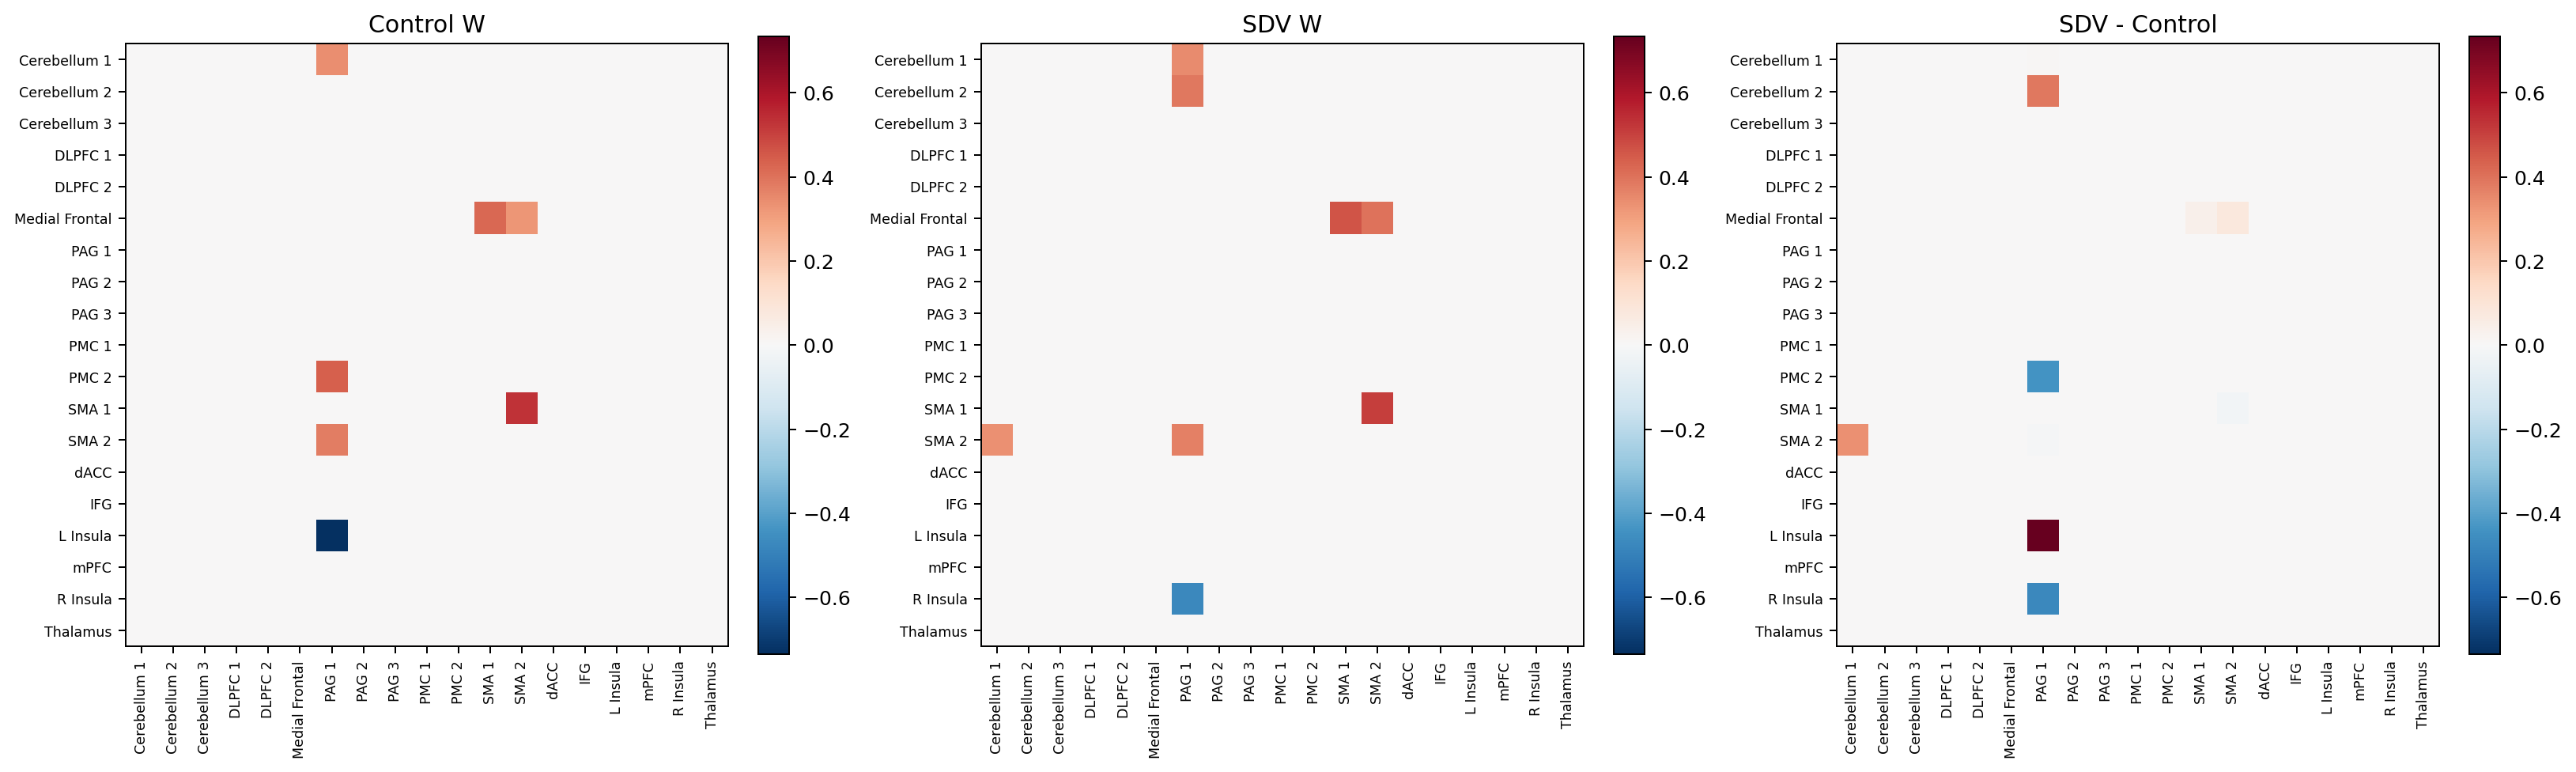

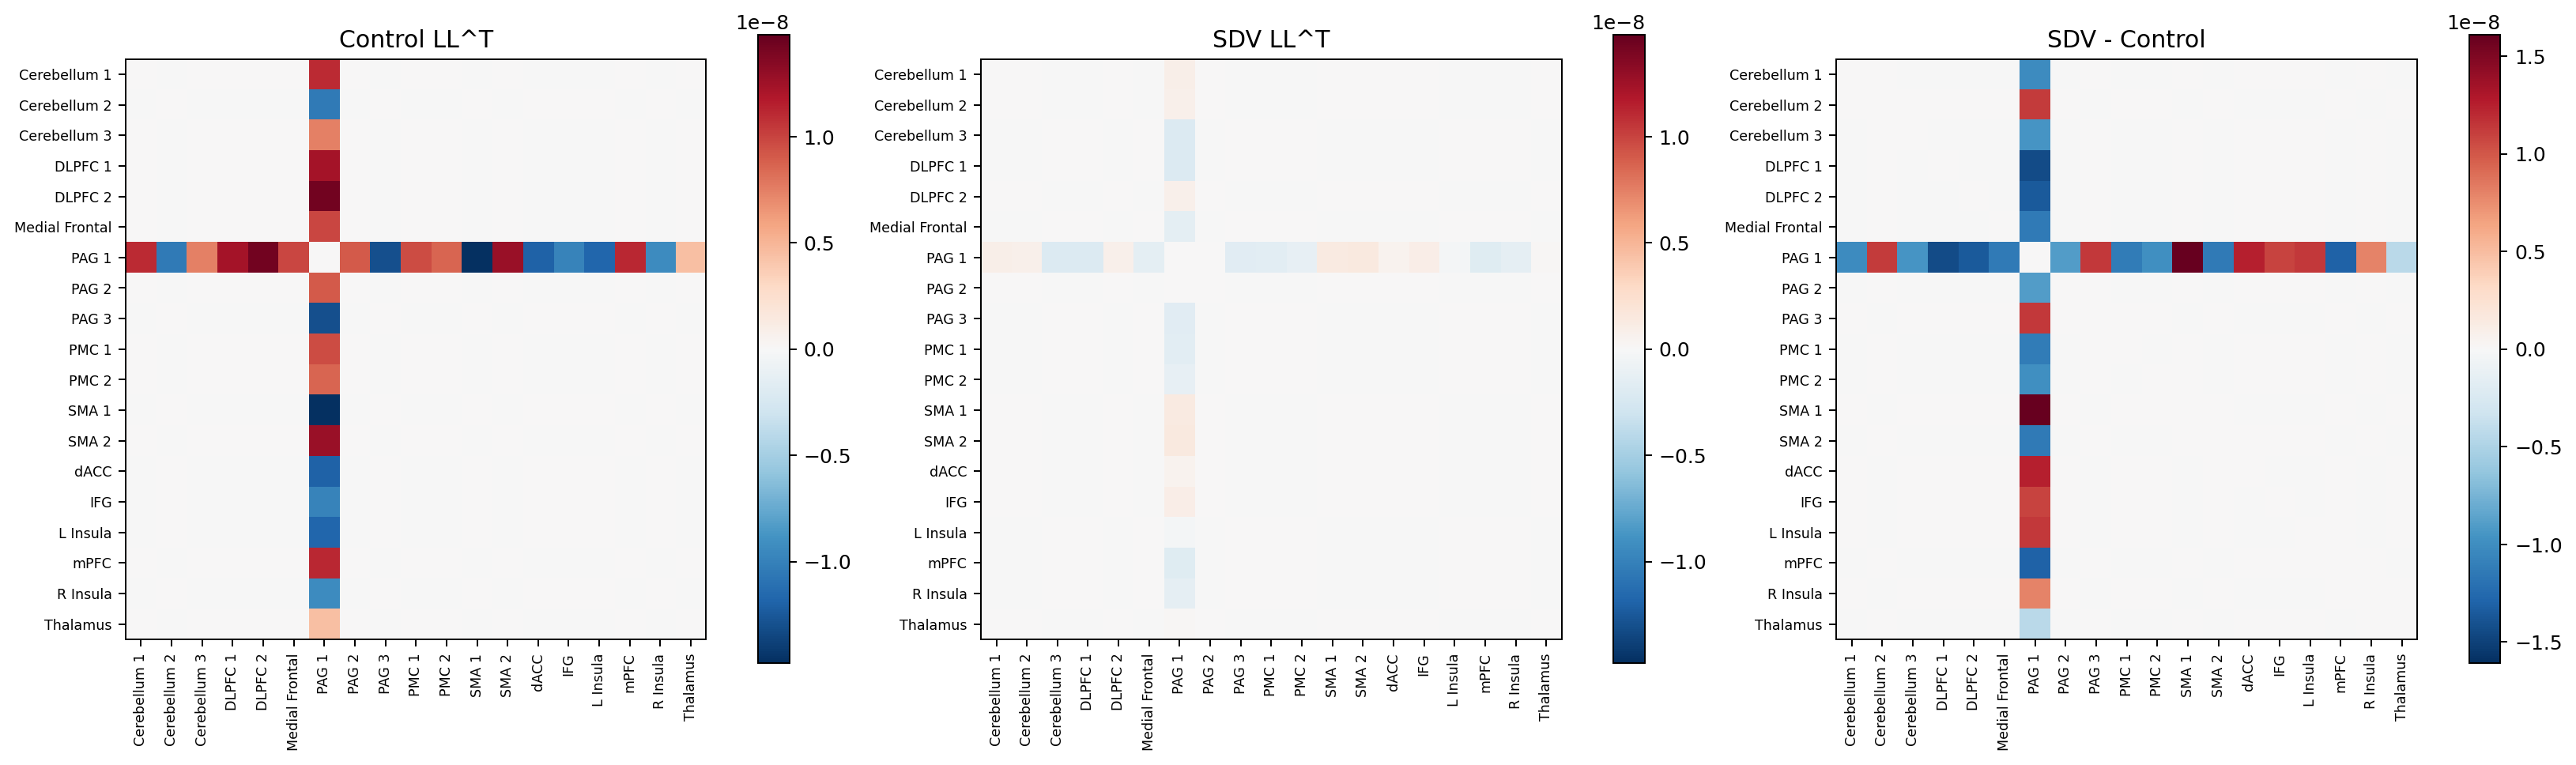

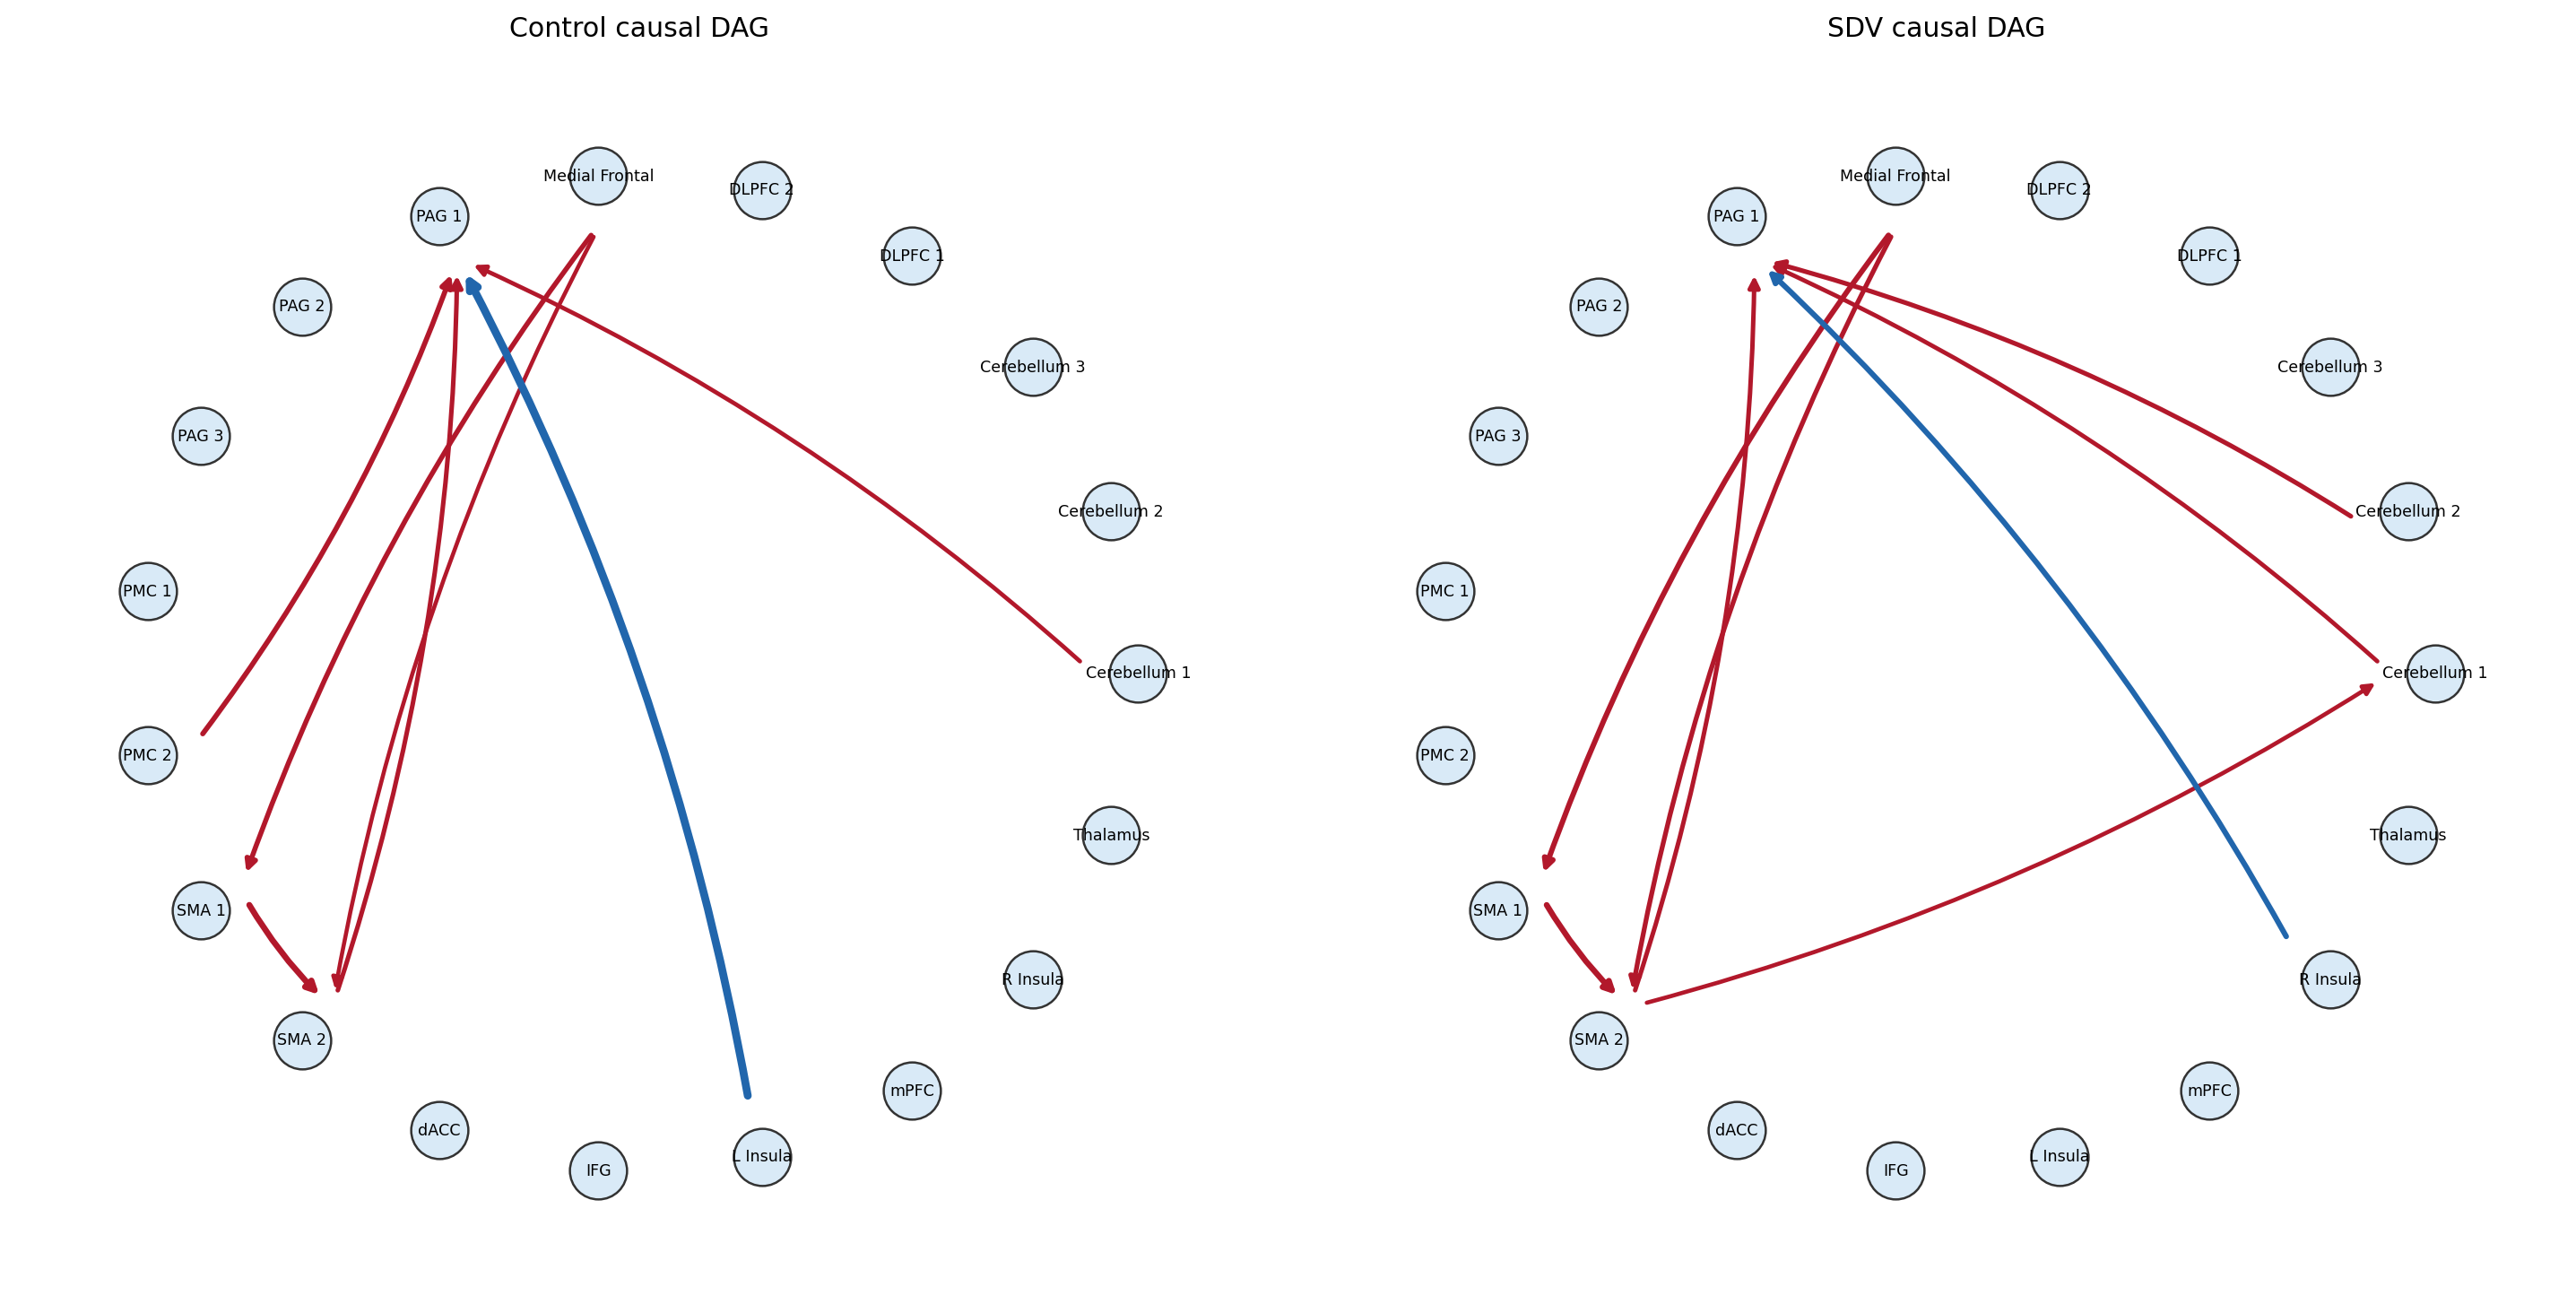

{'directed_edges': 7, 'directed_abs_sum': 3.1665328360140537, 'directed_abs_mean': 0.4523618337162934, 'W_fro': 1.2463279554831819, 'h': 0.0, 'latent_fro': 3.144244095620088e-06, 'latent_offdiag_abs_mean': 1.1542773894309552e-09}
{'directed_edges': 8, 'directed_abs_sum': 3.279884505144291, 'directed_abs_mean': 0.40998556314303636, 'W_fro': 1.1717091373940278, 'h': 0.0, 'latent_fro': 3.614382366765747e-07, 'latent_offdiag_abs_mean': 1.2194625790352412e-10}


In [14]:
S_control=latent_similarity(static_control); S_sdv=latent_similarity(static_sdv)
plot_matrix_comparison(static_control.W0,static_sdv.W0,BLADDER19_LABELS,('Control W','SDV W','SDV - Control'),OUTPUT/'static_W_comparison.png')
plot_matrix_comparison(S_control,S_sdv,BLADDER19_LABELS,('Control LL^T','SDV LL^T','SDV - Control'),OUTPUT/'static_latent_comparison.png',True)
plot_graph_comparison(static_control.W0,static_sdv.W0,BLADDER19_LABELS,OUTPUT/'static_graph_comparison.png',EDGE_THRESHOLD)
for filename in ('static_W_comparison.png','static_latent_comparison.png','static_graph_comparison.png'):
    display(Image(filename=str(OUTPUT/filename)))
print(model_statistics(static_control.W0,S_control,static_control.diagnostics['h_thresholded']))
print(model_statistics(static_sdv.W0,S_sdv,static_sdv.diagnostics['h_thresholded']))

In [28]:
import importlib
import causal_opt.fmri
importlib.reload(causal_opt.fmri)

<module 'causal_opt.fmri' from 'c:\\Users\\bayer\\PycharmProjects\\CausalOpt\\src\\causal_opt\\fmri.py'>

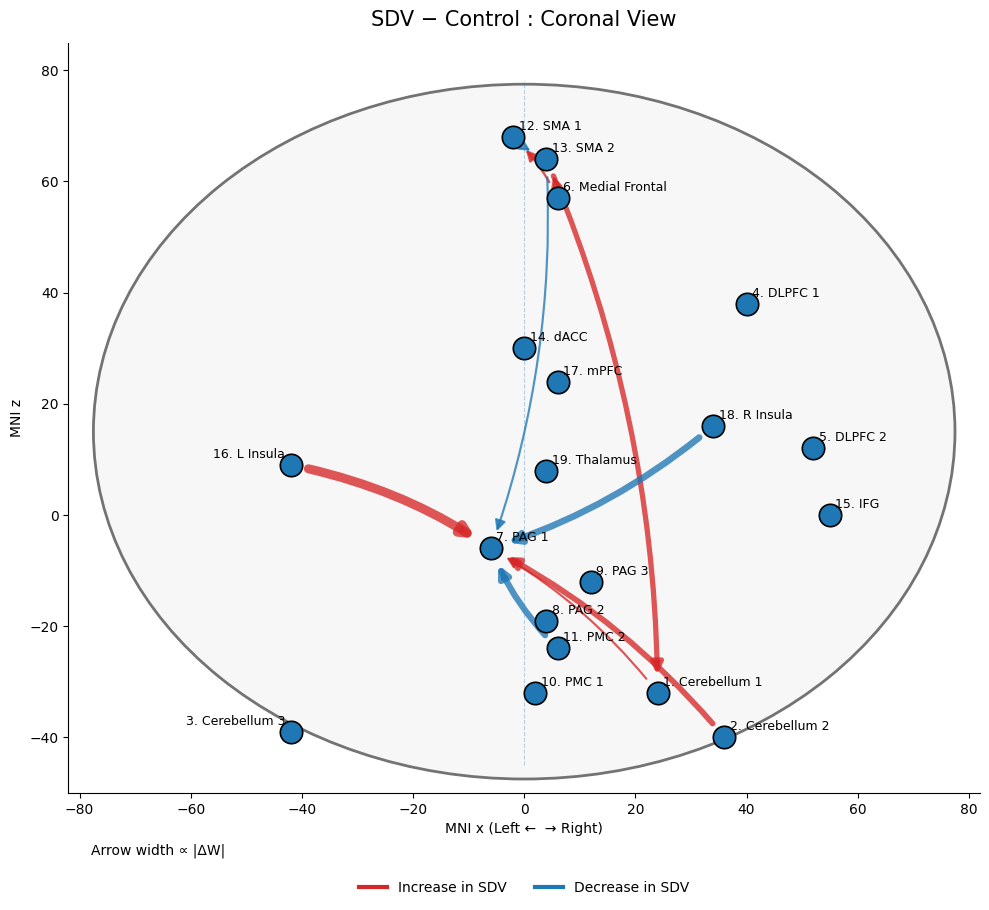

In [29]:
from causal_opt.fmri import BLADDER19_LABELS, plot_anatomical_graph_difference
import matplotlib.pyplot as plt

case2_difference_path = (
    OUTPUT / "case2_sdv_minus_control_coronal.png"
)

fig, ax = plot_anatomical_graph_difference(
    static_control.W0,
    static_sdv.W0,
    control.roi_xyz,
    BLADDER19_LABELS,
    output_path=case2_difference_path,
    view="coronal", # sagittal
    title="SDV − Control : Coronal View", # Sagittal View
)

plt.show()

## Case 2 — Baseline comparison
These cells load the official NOTEARS and endpoint-coded FCI results produced by the analysis script. FCI is summarized as a PAG; weighted-DAG metrics are intentionally shown as N/A.

,Method,State,Directed edges,Other/PAG edges,h(W),Fit loss
0,Proposed latent Case 2,Control,7,NaN,0.0,36.970056
1,Proposed latent Case 2,SDV,8,NaN,0.0,37.741085
2,Standard NOTEARS,Control,7,NaN,0.0,36.970058
3,Standard NOTEARS,SDV,8,NaN,0.0,37.733771
4,FCI,Control,7,94.0,NaN,NaN
5,FCI,SDV,3,120.0,NaN,NaN


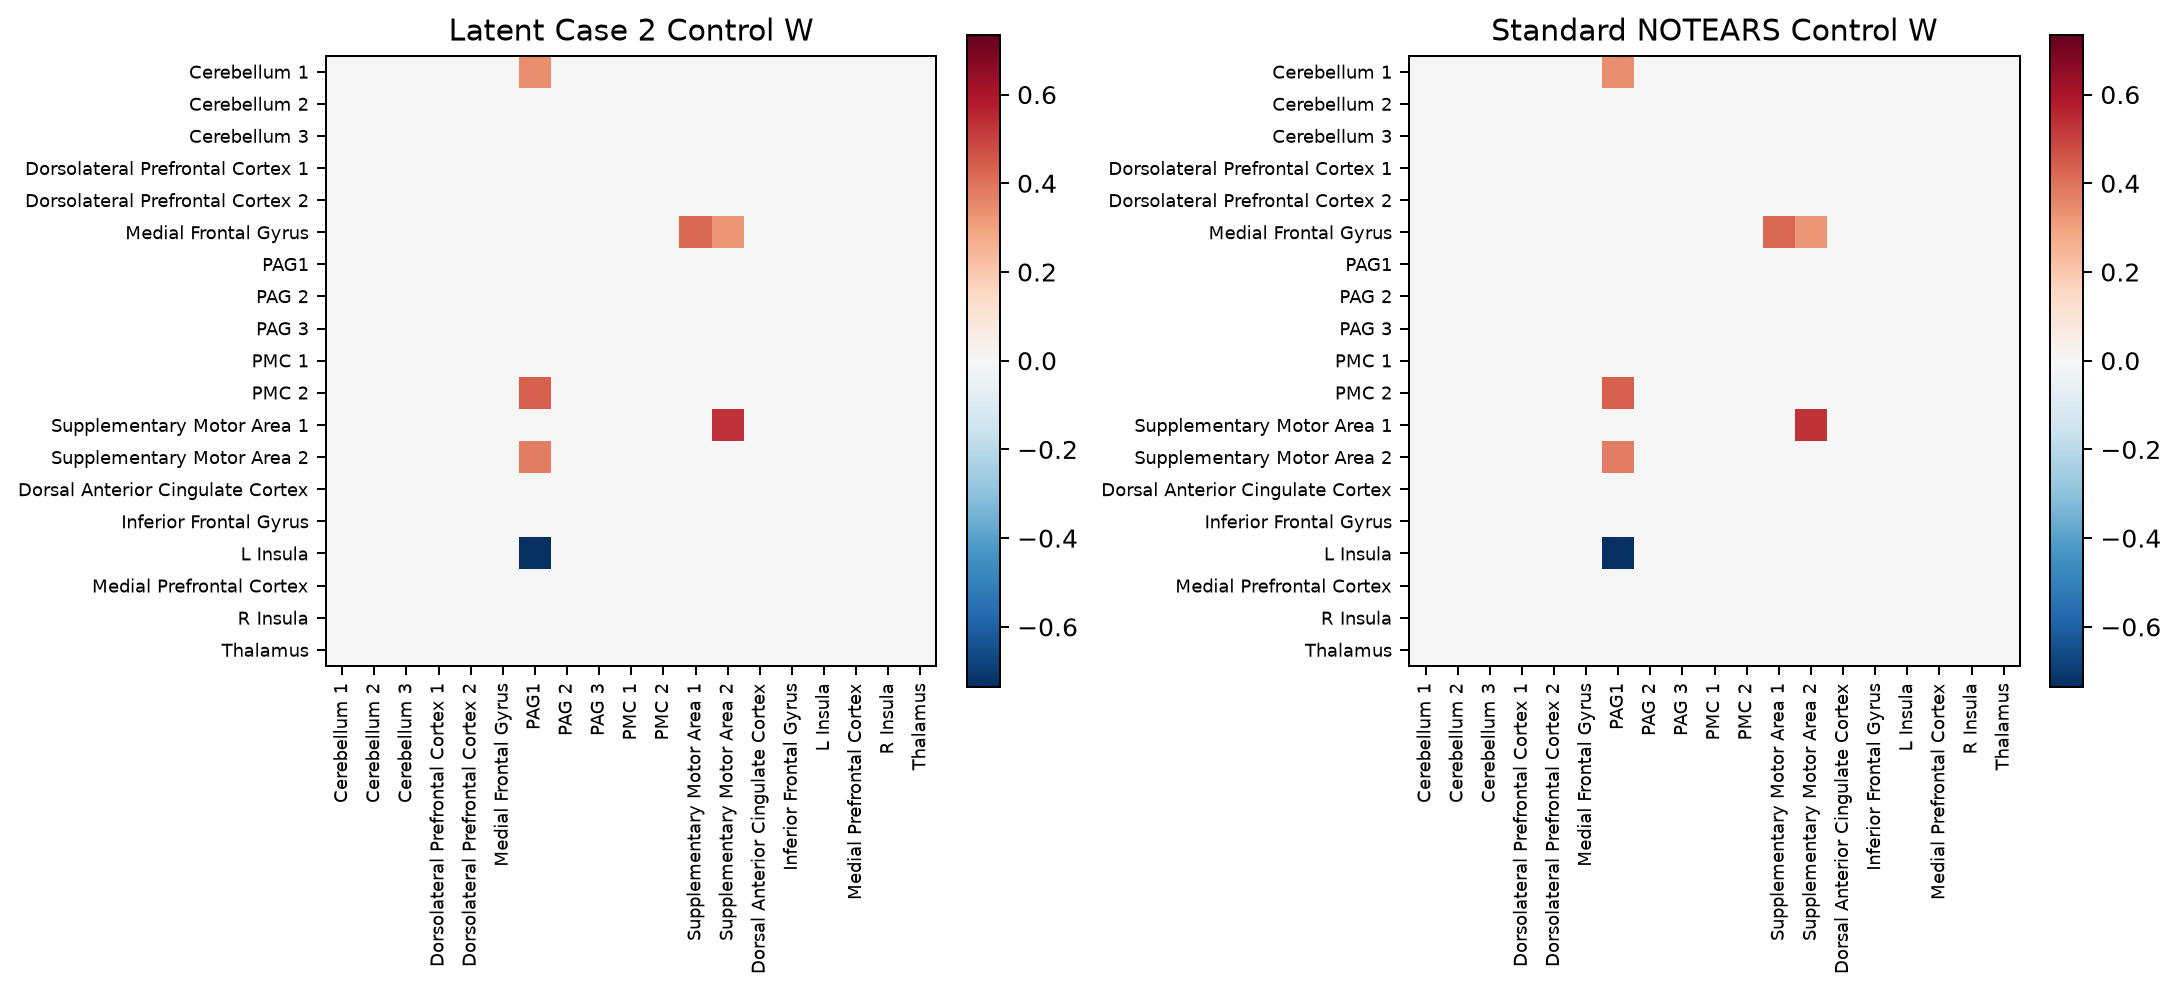

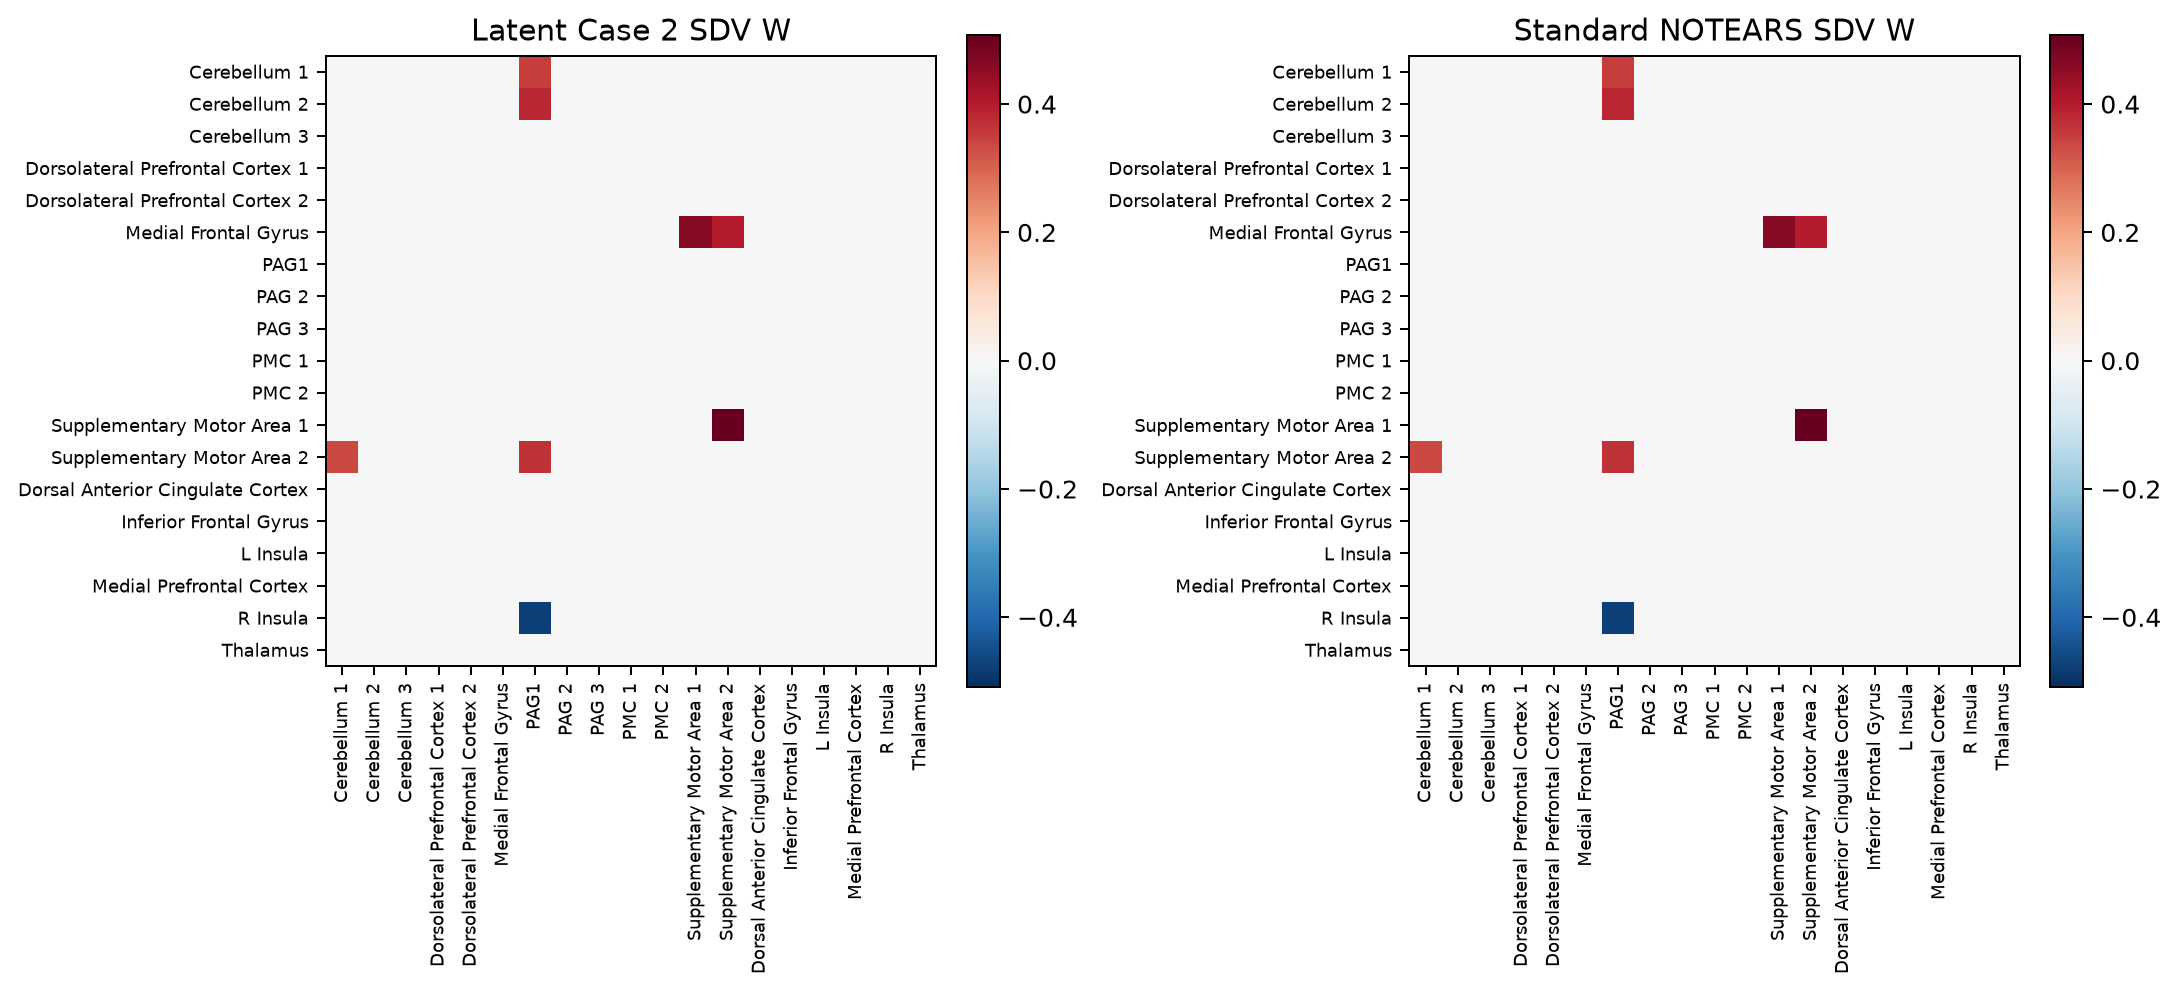

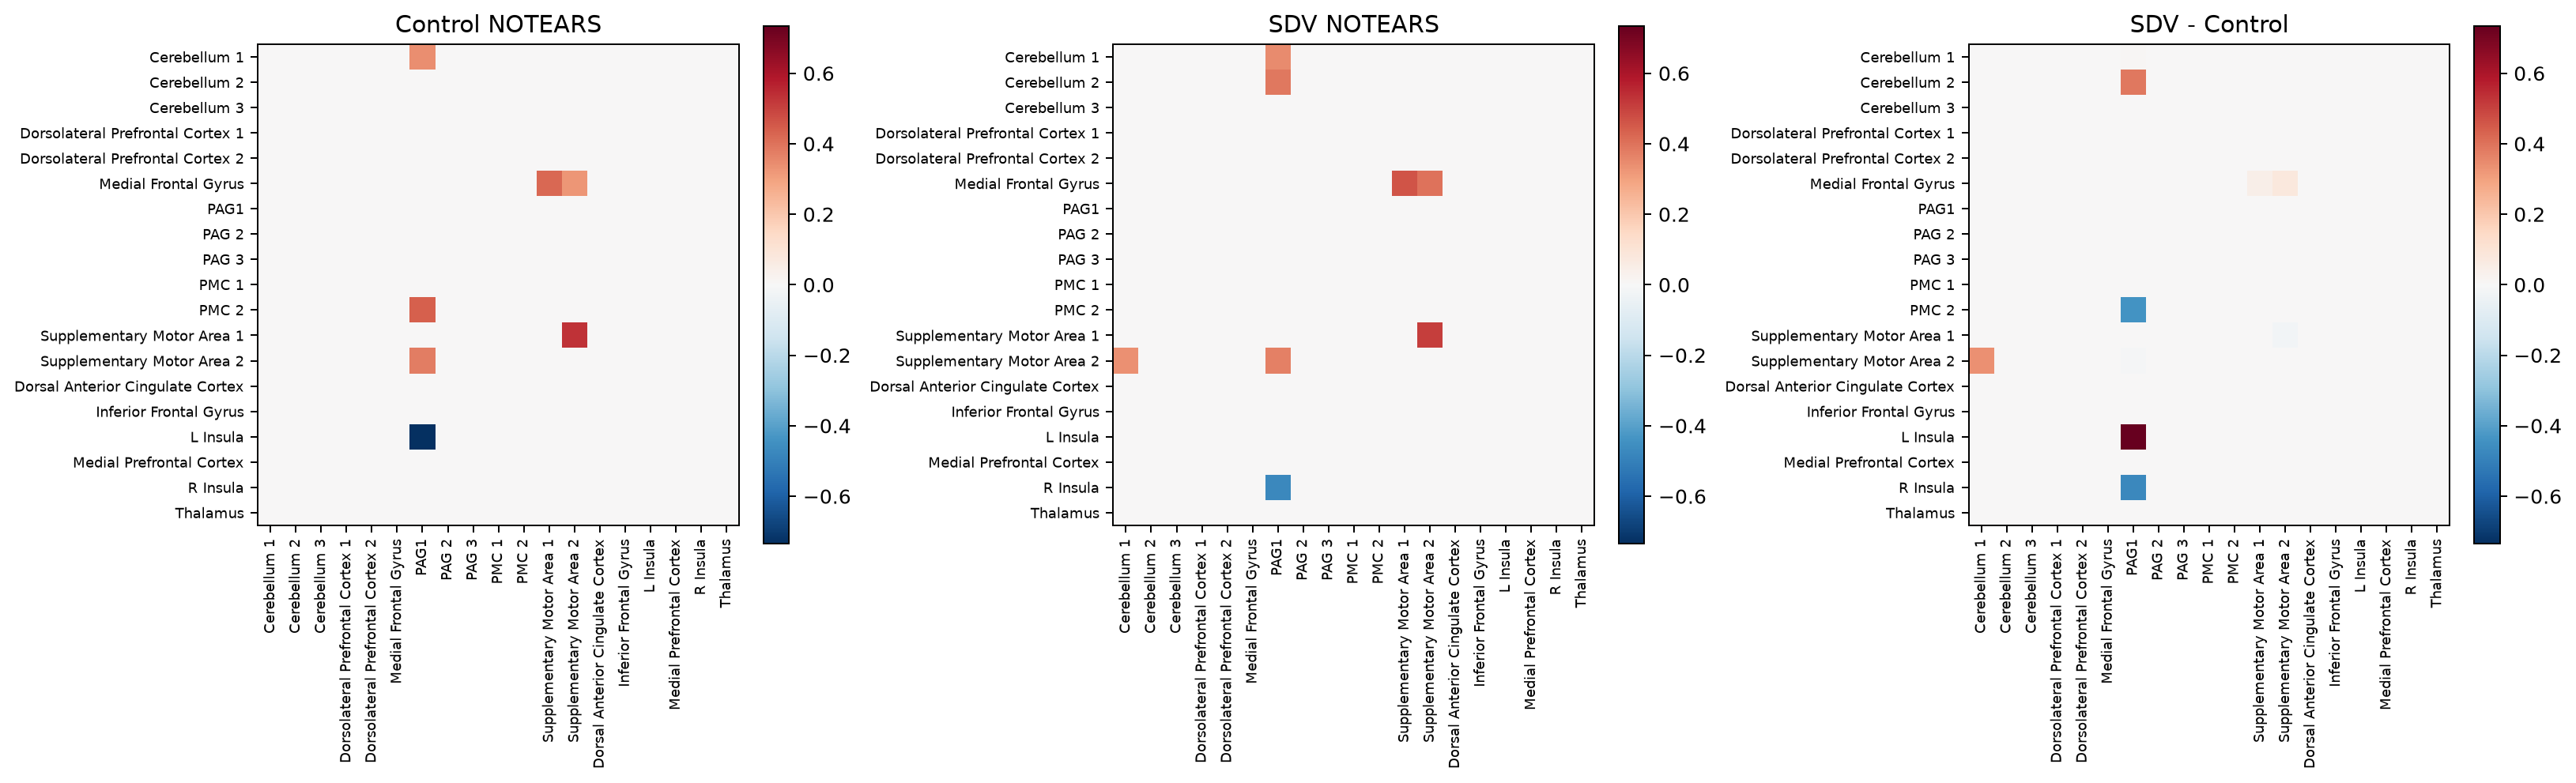

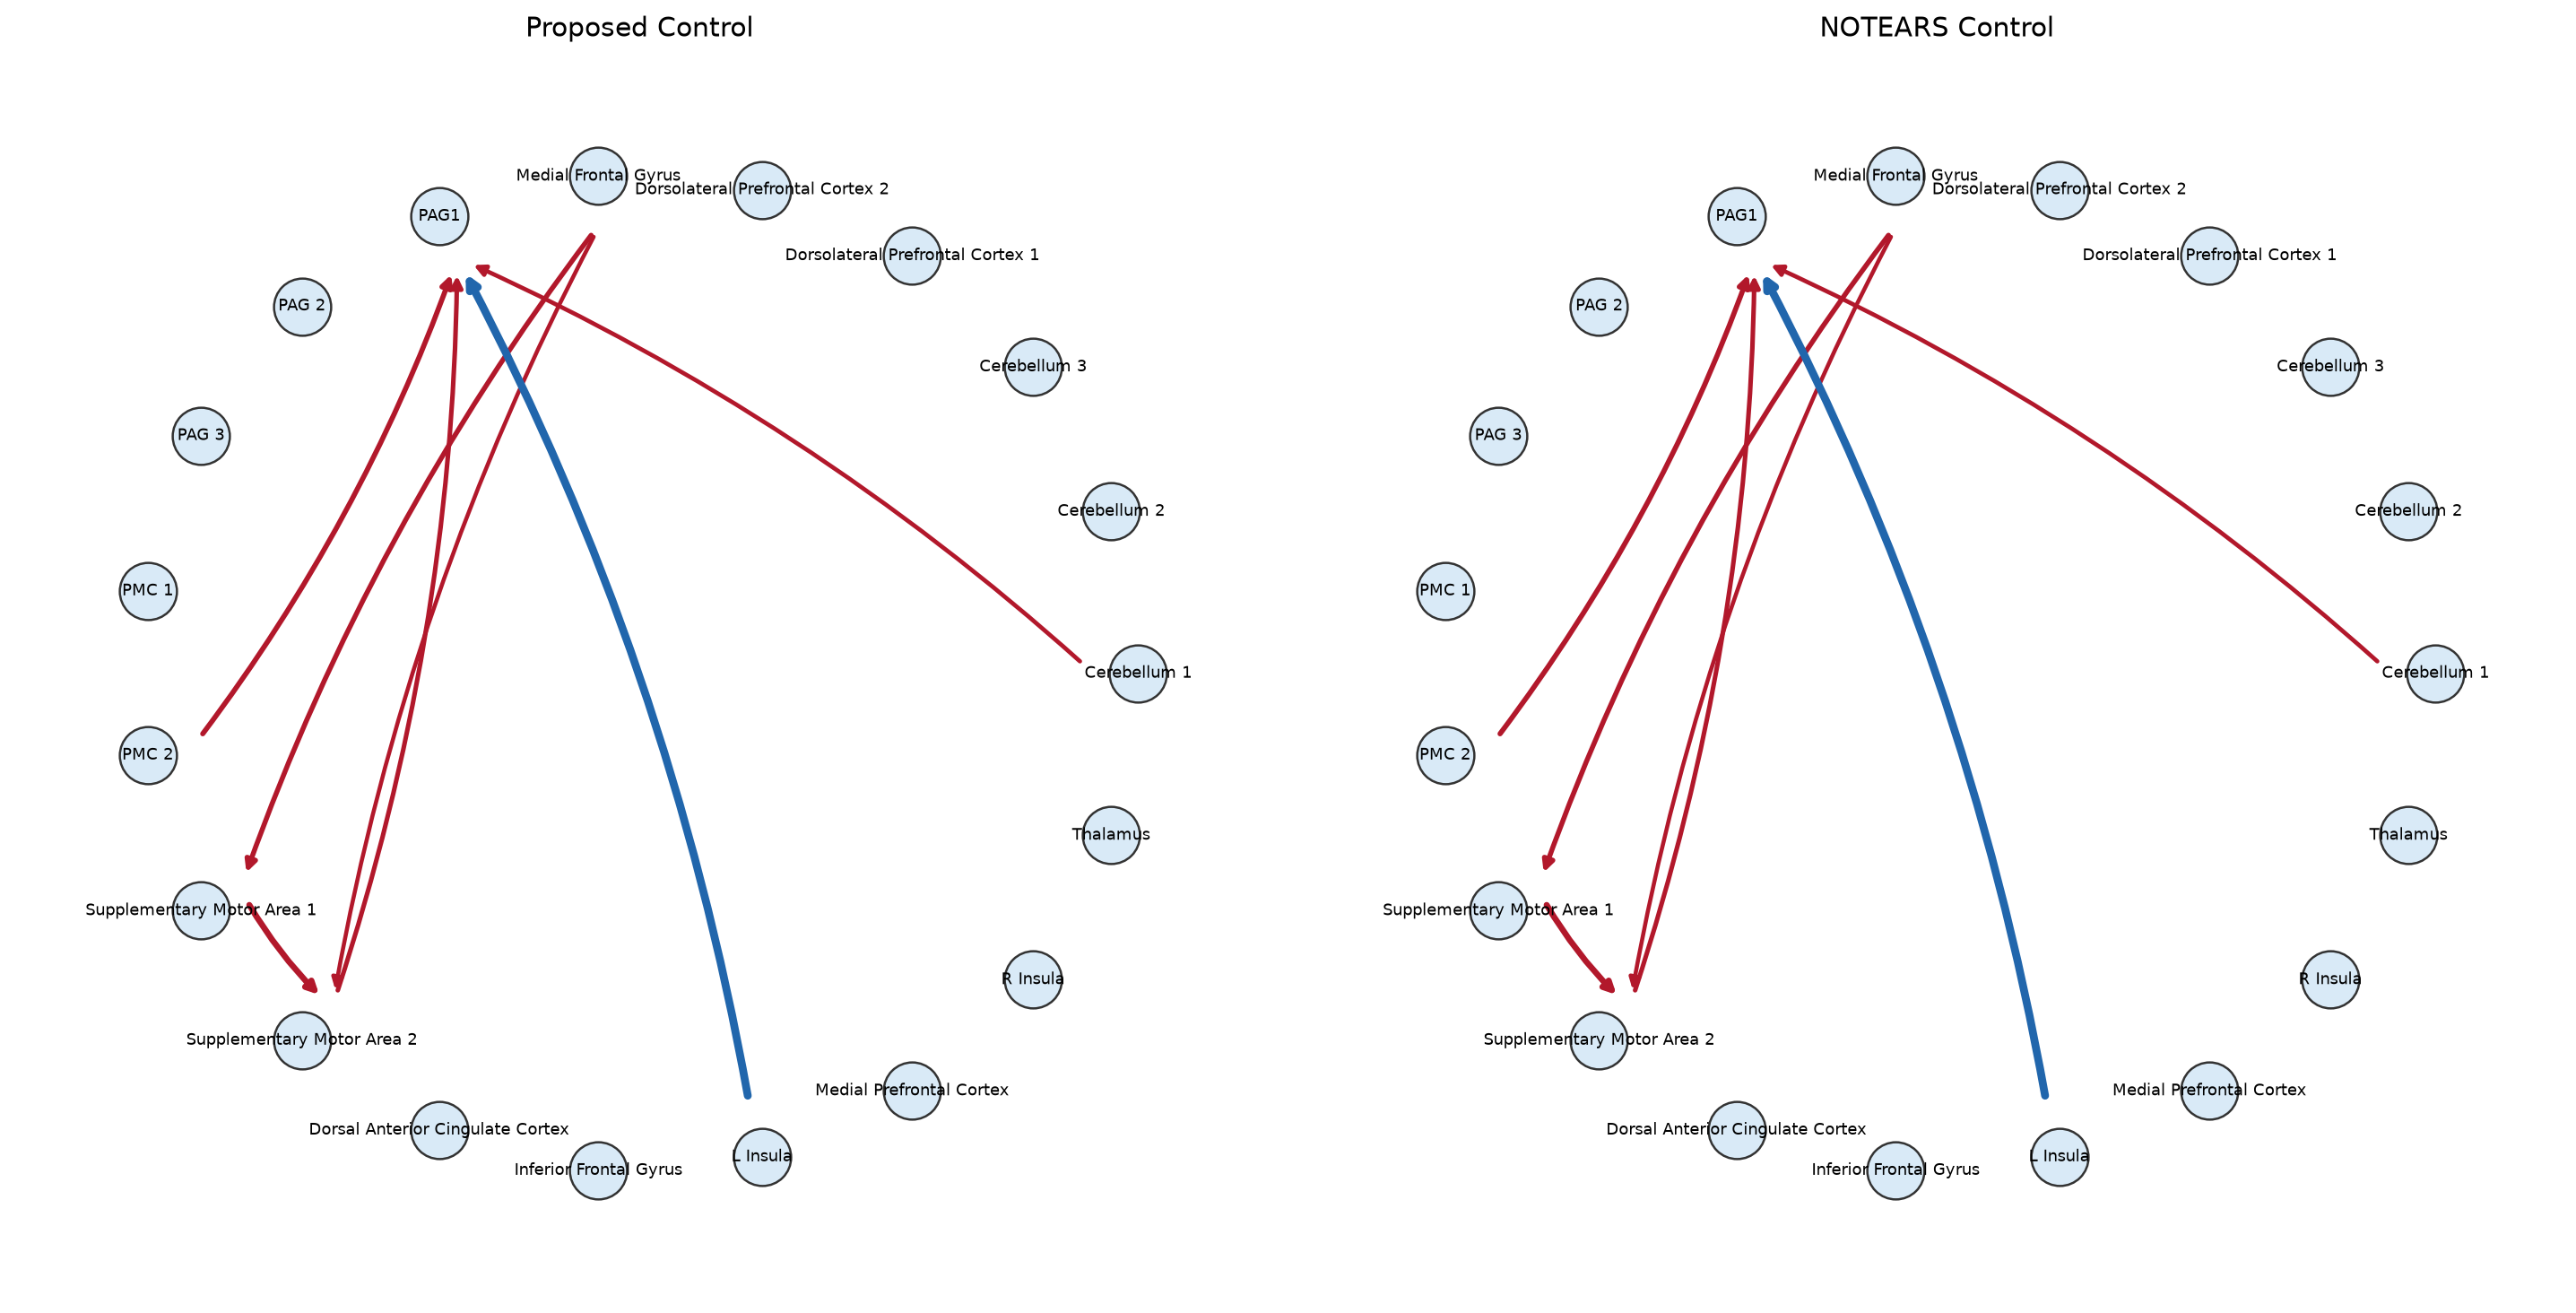

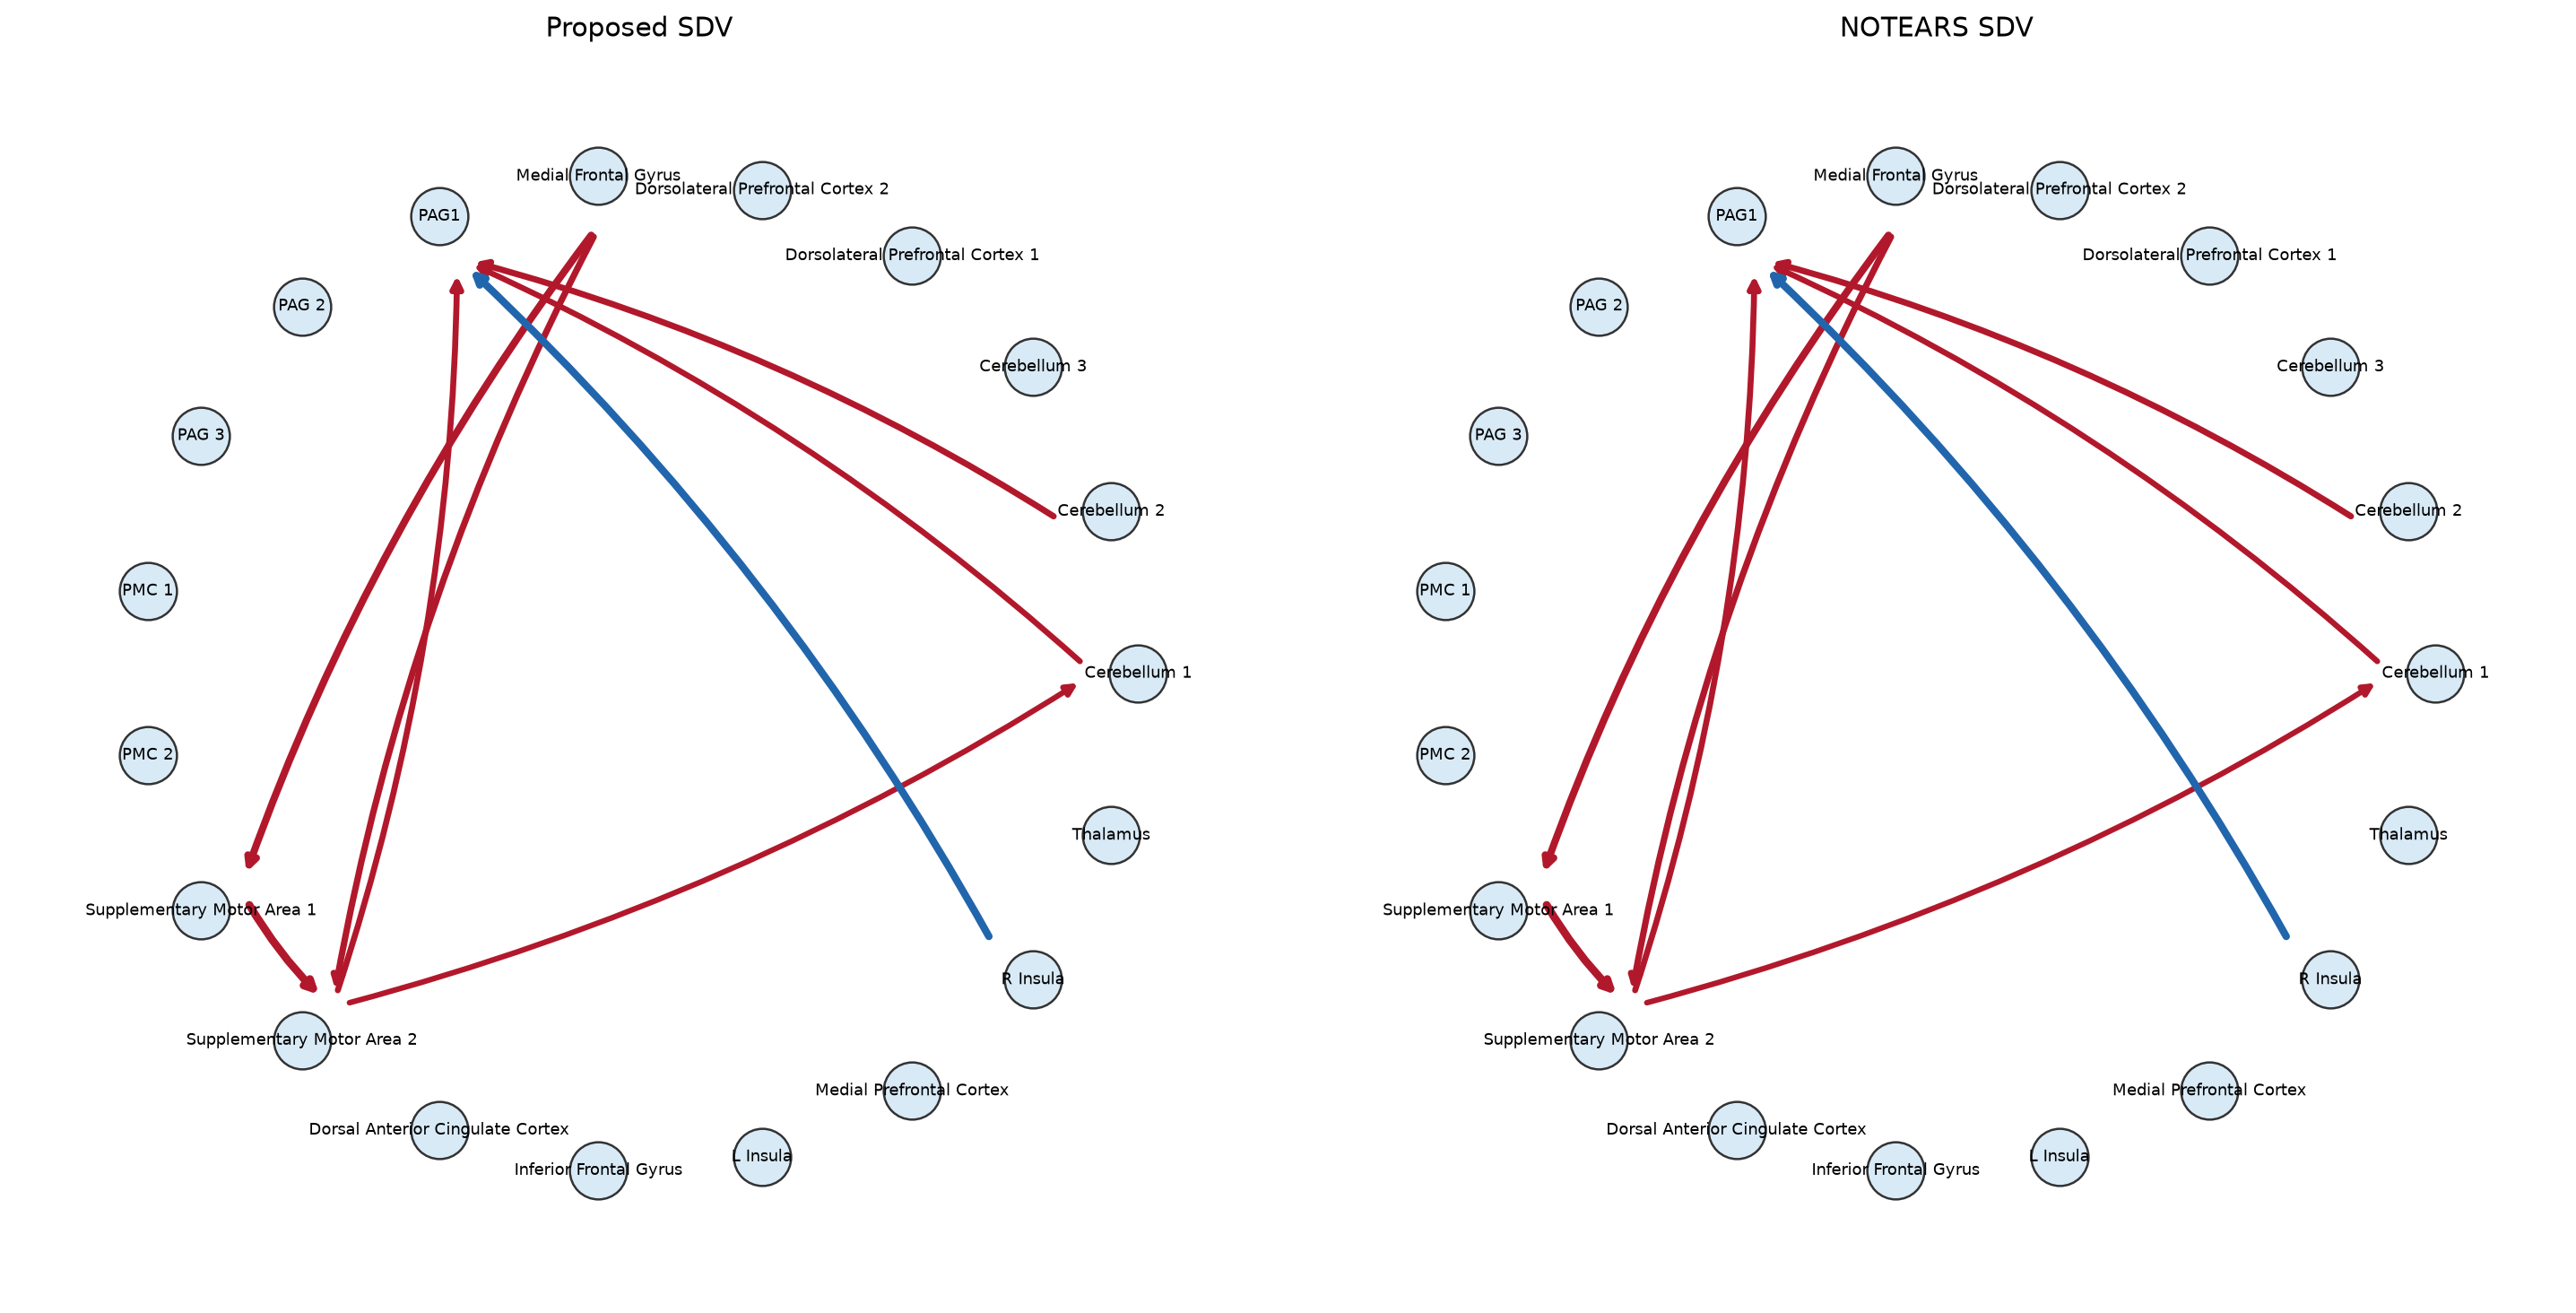

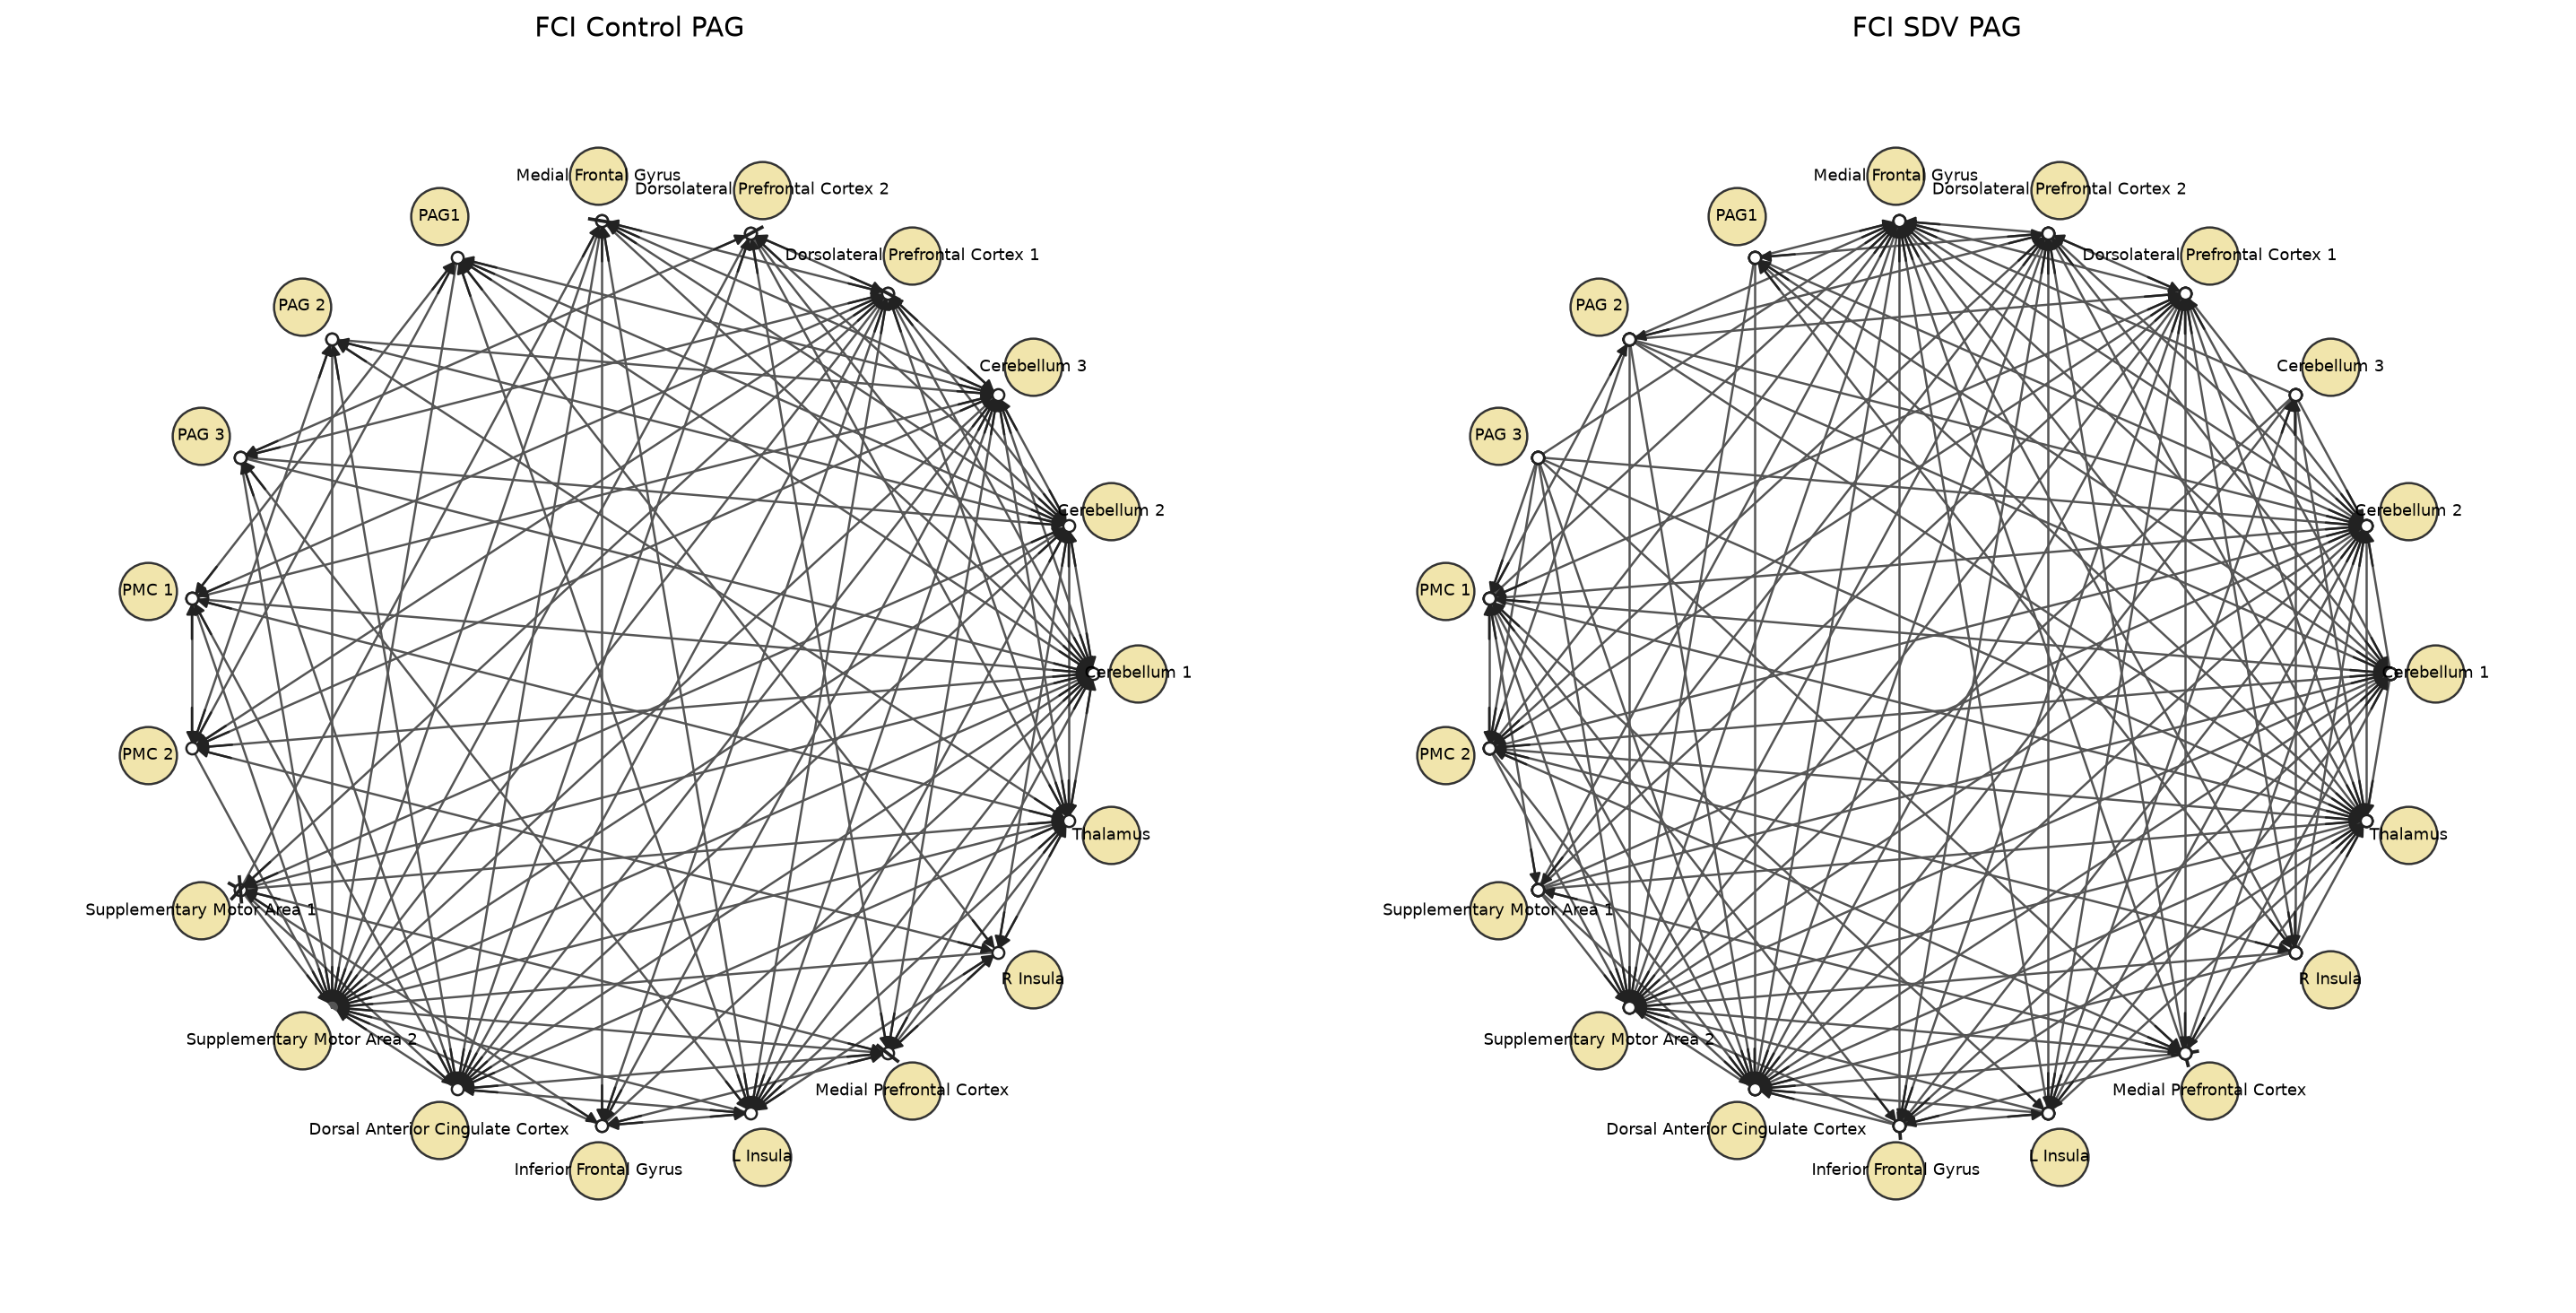

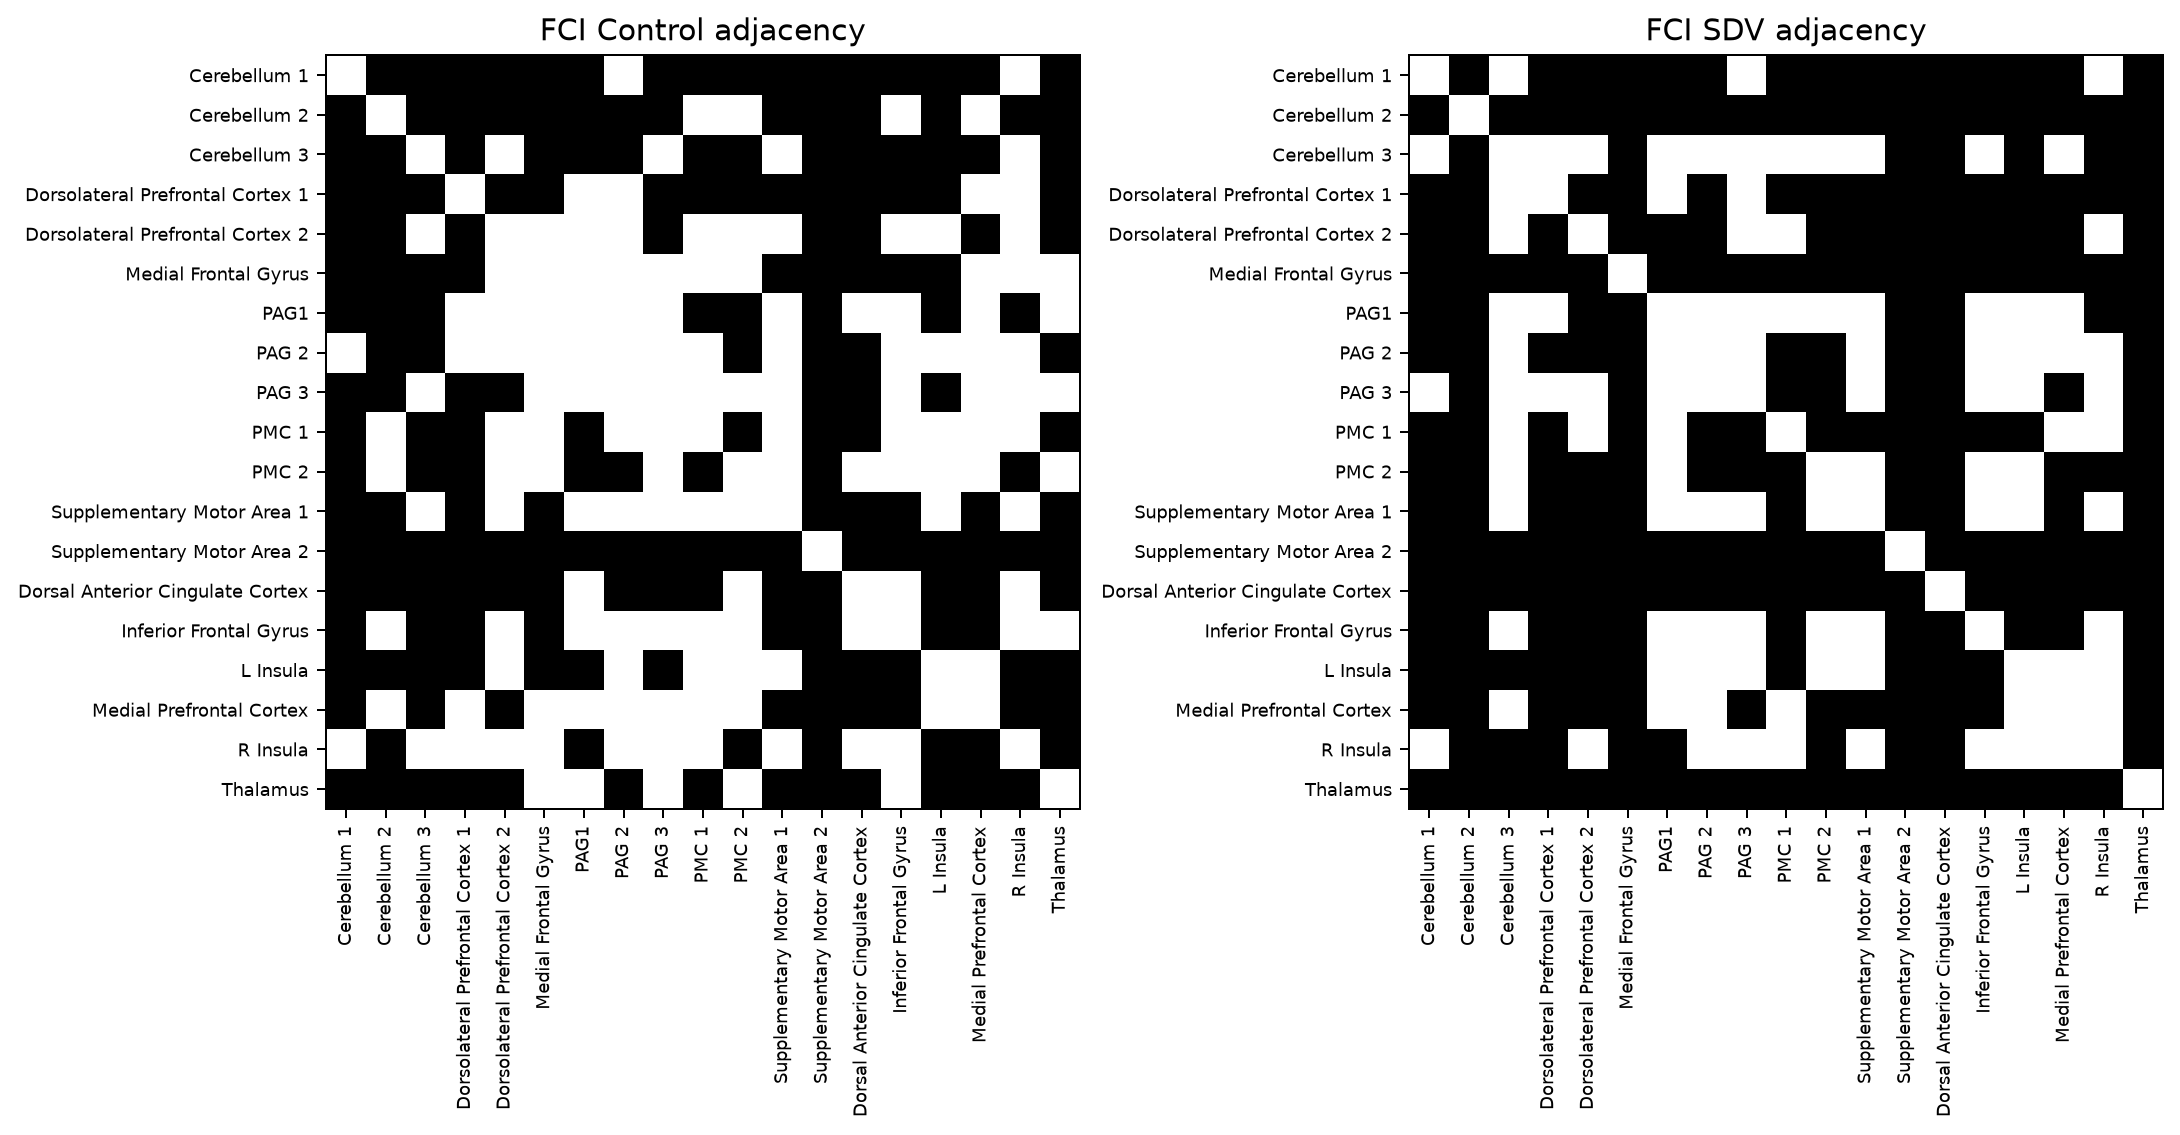

In [5]:
import pandas as pd
INFERENCE_OUTPUT=Path(os.getenv('FMRI_INFERENCE_OUTPUT',ROOT/'results'/'fmri_case2_inference'))
baseline_csv=INFERENCE_OUTPUT/'case2_baseline_summary.csv'
if baseline_csv.exists():
    baseline_summary=pd.read_csv(baseline_csv)
    display(baseline_summary)
    for filename in ('static_control_proposed_vs_notears.png','static_sdv_proposed_vs_notears.png','notears_W_comparison.png','static_control_proposed_vs_notears_graph.png','static_sdv_proposed_vs_notears_graph.png','fci_pag_comparison.png','fci_skeleton_comparison.png'):
        path=INFERENCE_OUTPUT/filename
        if path.exists(): display(Image(filename=str(path)))
else:
    print('Cached baseline results not found. Run scripts/run_fmri_causal_analysis.py --static-only --case2-baselines first.')

## Case 2 — Patient-wise bootstrap inference
The statistical unit is the paired subject. These cells only load resumable cached bootstrap fits; opening the notebook never launches 1,000 optimizations. Inference uses raw, pre-threshold W matrices.

{'off_diagonal_tests': 342, 'fdr_supported_edges': 0}


,result
0,No edge survives BH FDR at q < 0.05.


,source_index,source_name,target_index,target_name,W_control_observed,W_sdv_observed,delta_W_observed,bootstrap_mean_delta,bootstrap_median_delta,ci_2.5,ci_97.5,p_boot,q_fdr,ci_excludes_zero,fdr_significant,control_selection_probability,sdv_selection_probability,control_positive_probability,sdv_positive_probability
0,15,L Insula,6,PAG1,-0.734679,0.000000,0.734679,0.523302,0.510654,-0.015402,1.197014,0.142857,1.0,False,False,0.55,0.15,0.05,0.45
1,1,Cerebellum 2,6,PAG1,-0.273724,0.384724,0.658448,0.802680,0.761864,0.383557,1.144691,0.047619,1.0,True,False,0.75,0.75,0.00,1.00
2,10,PMC 2,6,PAG1,0.436544,-0.010167,-0.446710,-0.466975,-0.452951,-0.930317,-0.187860,0.095238,1.0,True,False,0.60,0.00,1.00,0.15
3,3,Dorsolateral Prefrontal Cortex 1,6,PAG1,0.137179,-0.203016,-0.340195,-0.418602,-0.428606,-0.592311,-0.236952,0.047619,1.0,True,False,0.00,0.30,1.00,0.00
4,17,R Insula,2,Cerebellum 3,0.000000,-0.297949,-0.297949,-0.277837,-0.306702,-0.512052,-0.006126,0.095238,1.0,True,False,0.00,0.55,0.15,0.00
5,14,Inferior Frontal Gyrus,6,PAG1,-0.170984,0.108222,0.279206,0.268972,0.234178,-0.049965,0.593562,0.190476,1.0,False,False,0.15,0.05,0.10,0.90
6,12,Supplementary Motor Area 2,8,PAG 3,0.248142,0.000000,-0.248142,-0.235389,-0.249574,-0.346064,-0.093934,0.047619,1.0,True,False,0.35,0.05,1.00,0.20
7,5,Medial Frontal Gyrus,6,PAG1,0.178200,-0.065994,-0.244194,-0.352431,-0.266262,-0.888423,0.110345,0.476190,1.0,False,False,0.25,0.15,0.70,0.05
8,16,Medial Prefrontal Cortex,6,PAG1,0.067440,-0.165757,-0.233196,-0.182555,-0.174303,-0.379292,-0.019929,0.047619,1.0,True,False,0.05,0.00,0.85,0.05
9,12,Supplementary Motor Area 2,0,Cerebellum 1,0.107986,0.335093,0.227108,0.264132,0.282256,0.023936,0.554229,0.190476,1.0,True,False,0.00,0.65,0.75,1.00


,roi,incoming_change,outgoing_change,total_change
0,PAG1,3.825763,0.004838,3.830601
1,Cerebellum 2,0.921710,0.862161,1.783871
2,Cerebellum 3,1.390412,0.269633,1.660046
3,Thalamus,0.676076,0.952834,1.628910
4,Dorsal Anterior Cingulate Cortex,0.352026,1.152390,1.504416
5,L Insula,0.098611,1.234046,1.332657
6,Inferior Frontal Gyrus,0.580433,0.616226,1.196659
7,Cerebellum 1,0.484884,0.703852,1.188737
8,Supplementary Motor Area 2,0.099341,1.040401,1.139742
9,PMC 2,0.519208,0.583605,1.102813


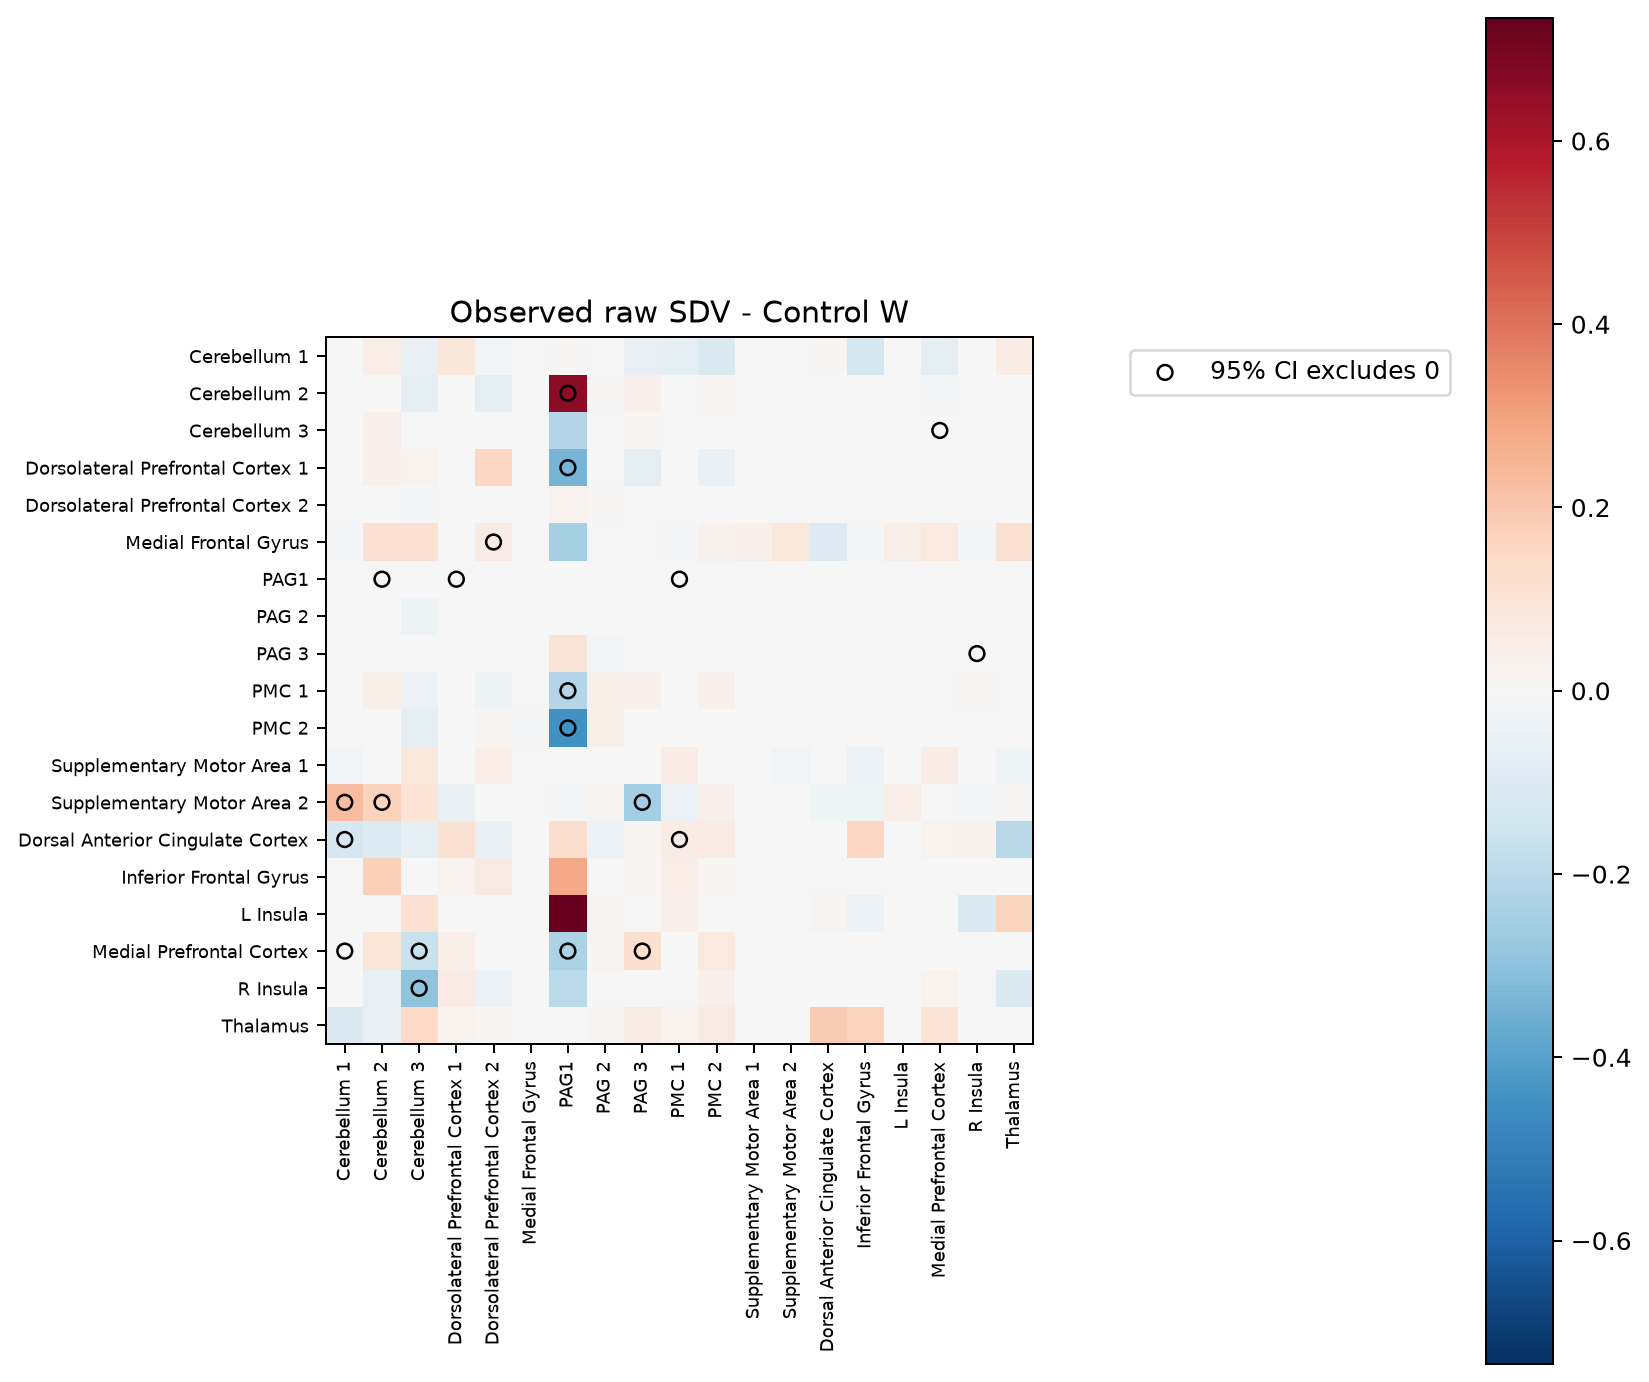

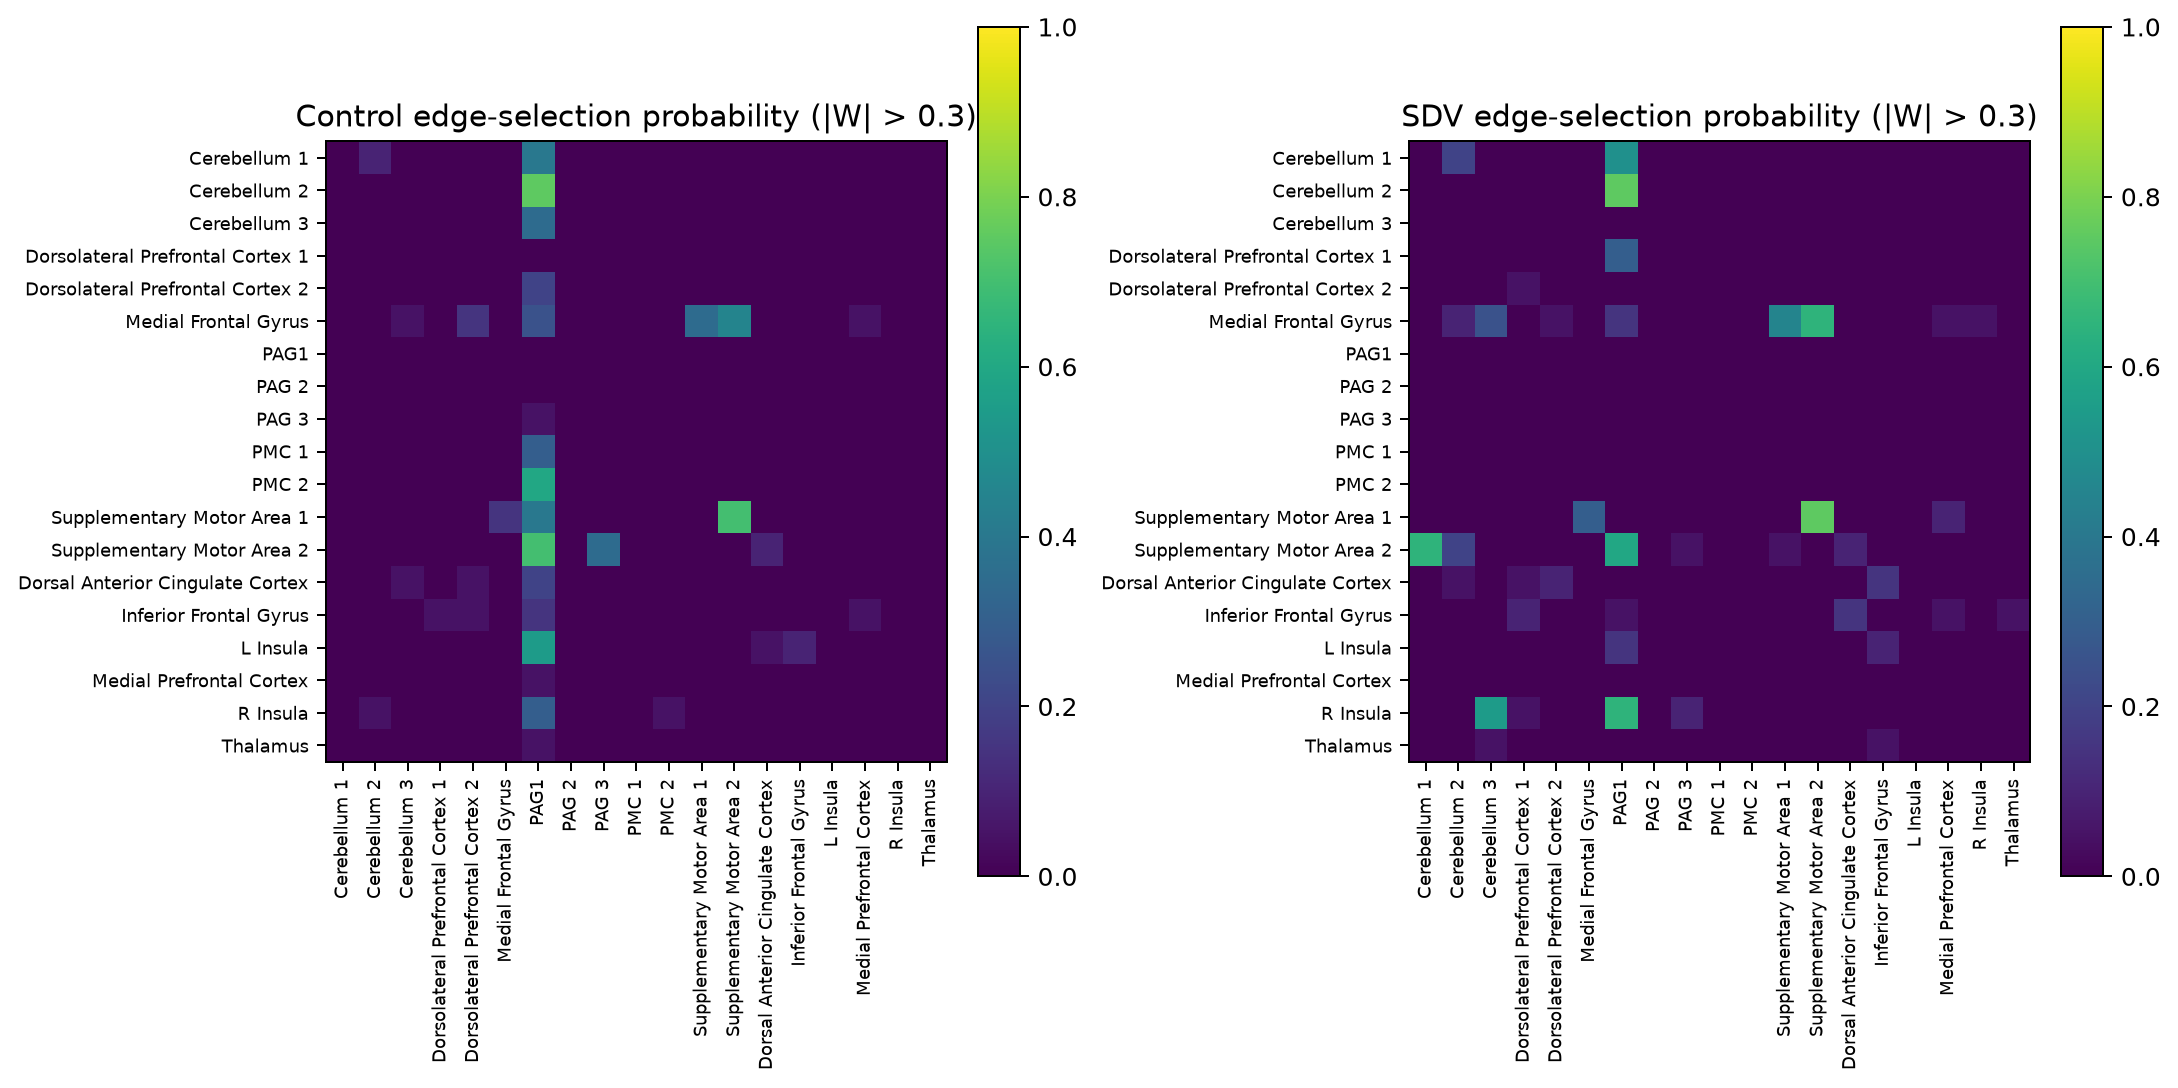

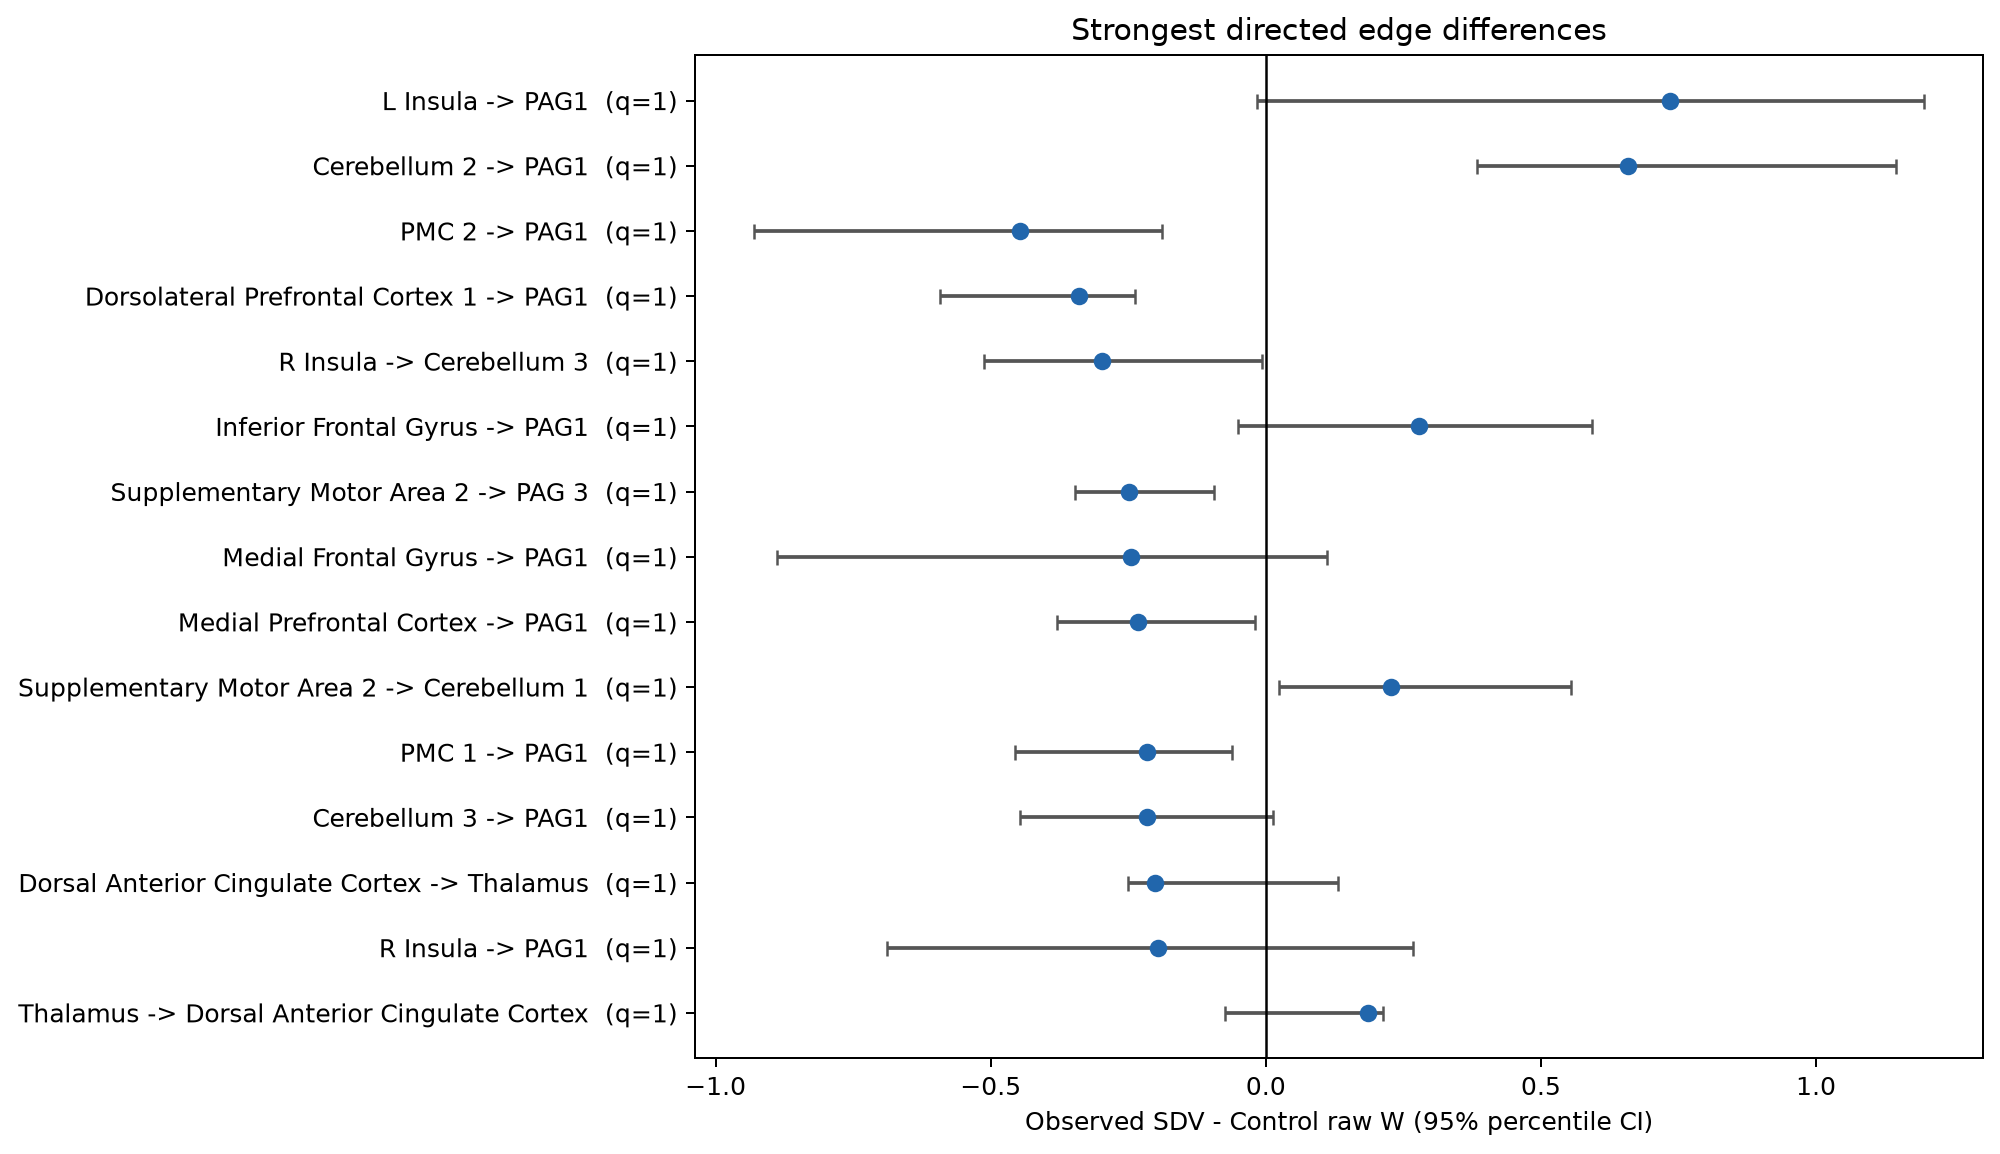

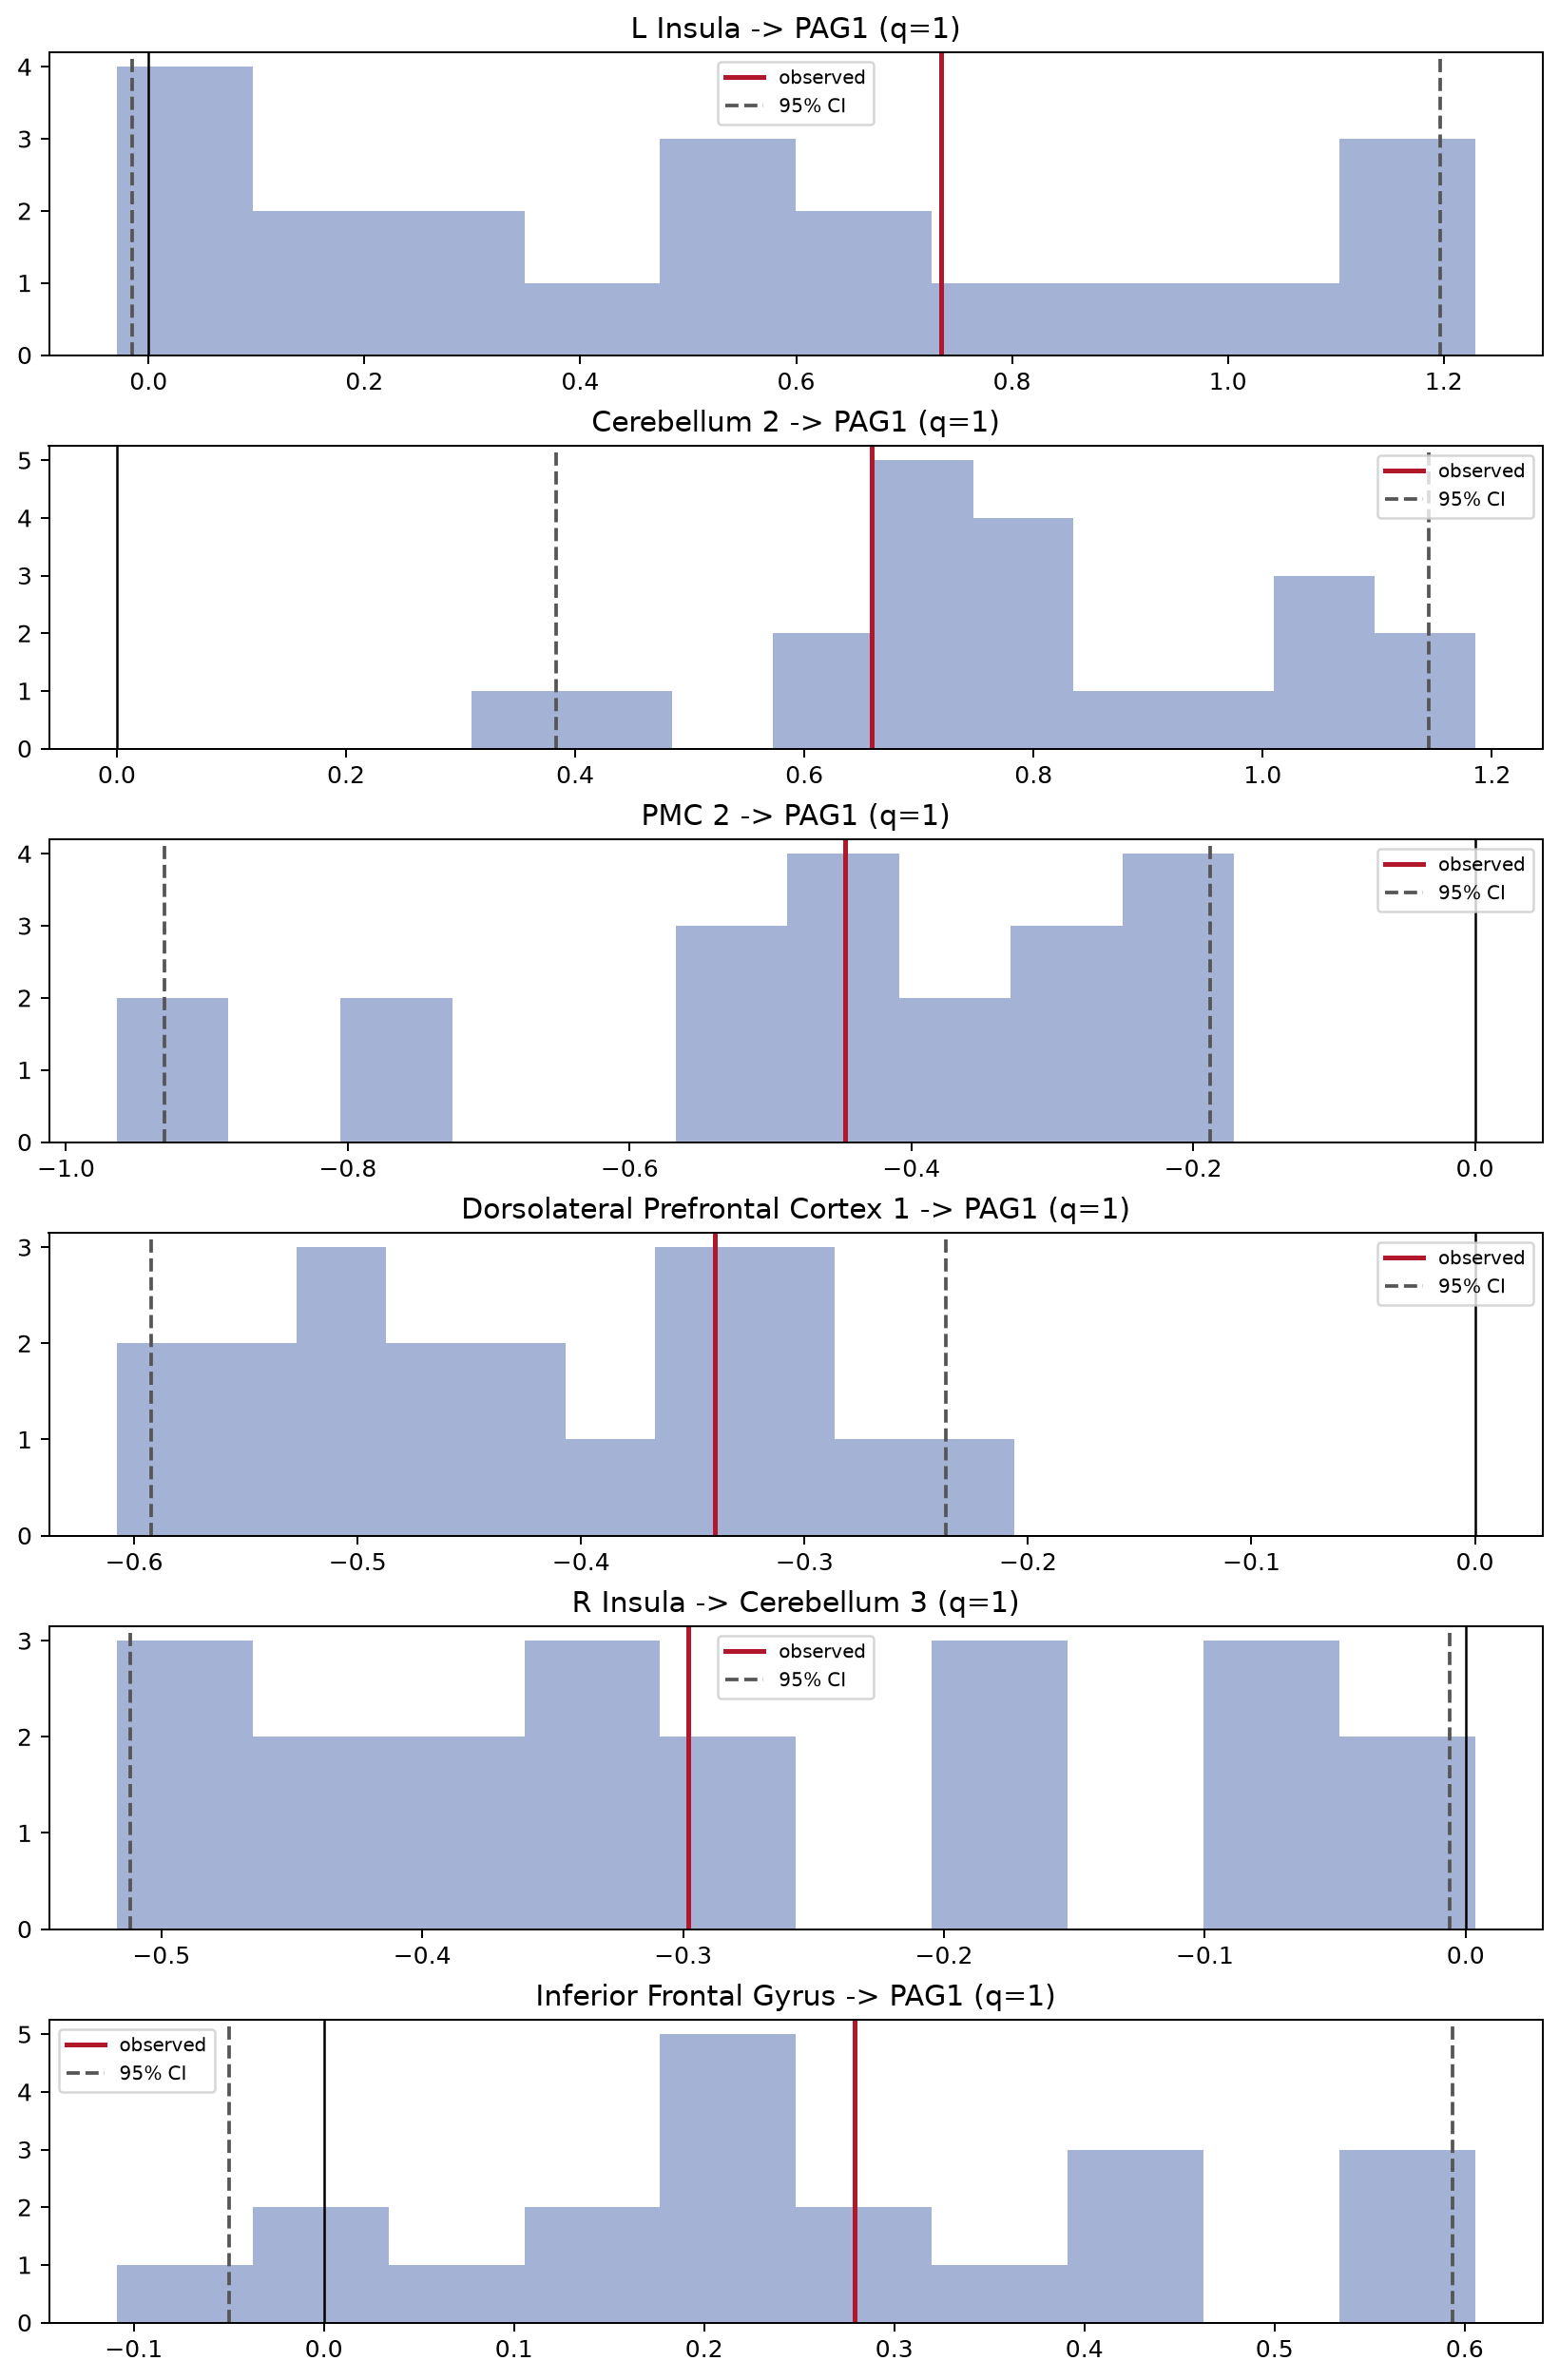

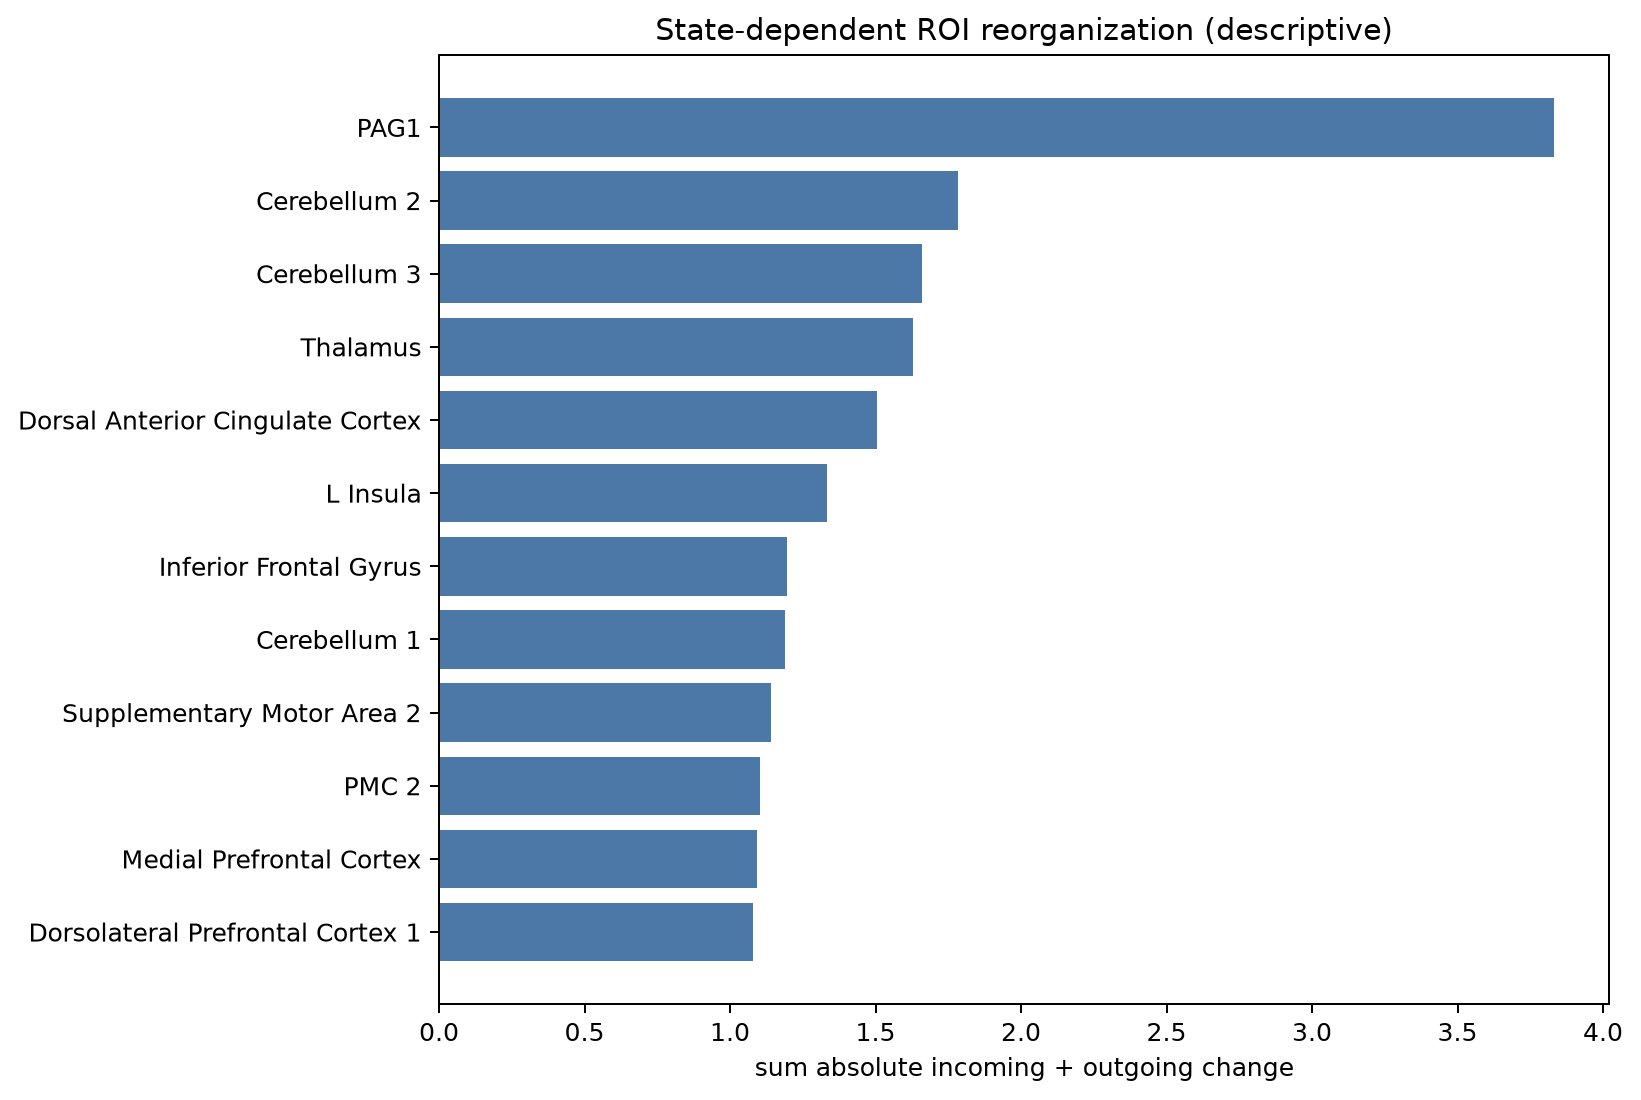

In [6]:
bootstrap_dir=INFERENCE_OUTPUT/'case2_bootstrap'
edge_csv=INFERENCE_OUTPUT/'case2_bootstrap_edge_results.csv'
if edge_csv.exists():
    edge_results=pd.read_csv(edge_csv)
    fdr_edges=edge_results[edge_results.fdr_significant.astype(bool)]
    print({'off_diagonal_tests':len(edge_results),'fdr_supported_edges':len(fdr_edges)})
    display(fdr_edges if len(fdr_edges) else pd.DataFrame({'result':['No edge survives BH FDR at q < 0.05.']}))
    display(edge_results.head(20))
    nodes=pd.read_csv(INFERENCE_OUTPUT/'case2_node_reorganization.csv'); display(nodes.head(12))
    for filename in ('case2_bootstrap_delta_significance.png','case2_bootstrap_edge_stability.png','case2_bootstrap_edge_intervals.png','case2_bootstrap_key_edge_distributions.png','case2_node_reorganization.png'):
        path=INFERENCE_OUTPUT/filename
        if path.exists(): display(Image(filename=str(path)))
else:
    print('Cached bootstrap inference not found. Launch/resume it with --bootstrap-reps and --bootstrap-resume; the notebook will not refit it automatically.')

## 7. Case 4 — time-series latent-confounded causal model

In [7]:
X0c,Xlc,_=build_multisubject_lagged_data(control,P); X0s,Xls,_=build_multisubject_lagged_data(sdv,P)
print(X0c.shape,Xlc.shape,X0s.shape,Xls.shape)
dynamic_control=fit_dynamic_latent([control.timeseries[s] for s in control.subject_ids],P,**DYNAMIC)
dynamic_sdv=fit_dynamic_latent([sdv.timeseries[s] for s in sdv.subject_ids],P,**DYNAMIC)
print(dynamic_control.diagnostics); print(dynamic_sdv.diagnostics)

(3608, 19) (1, 3608, 19) (3609, 19) (1, 3609, 19)


{'objective': 22.708324036081237, 'fit_loss': 15.18514584734913, 'sparse_0_penalty': 0.33761811358014837, 'sparse_lag_penalty': 0.614271545271453, 'latent_penalty': 6.570867269603406, 'h_raw': 5.881418019271223e-09, 'h_thresholded': 0.0, 'rho': 10000000000000.0, 'peak_rho': 10000000000000.0, 'alpha': 101032.72114633495, 'outer_iterations': 11, 'total_inner_iterations': 5899, 'total_function_evaluations': 6001, 'optimizer_success': True, 'optimizer_status': 0, 'optimizer_message': 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', 'gradient_norm': 15.663814422474498, 'history': [{'outer_iter': 1, 'rho': 1.0, 'alpha': 0.0, 'h': 0.1076705620256142, 'fit_loss': 12.50238444952795, 'sparse_0_penalty': 0.714255670659171, 'sparse_lag_penalty': 0.5784204327484508, 'latent_penalty': 8.25800899629476, 'augmented_objective': 22.058866024193787, 'optimizer_success': True, 'optimizer_nit': 489, 'optimizer_nfev': 490, 'Z_fro_norm': 20.31987168348621, 'L_fro_norm': 20.320032342398754, 'C_fro_norm

## 8. Case 4 — Control vs SDV comparison

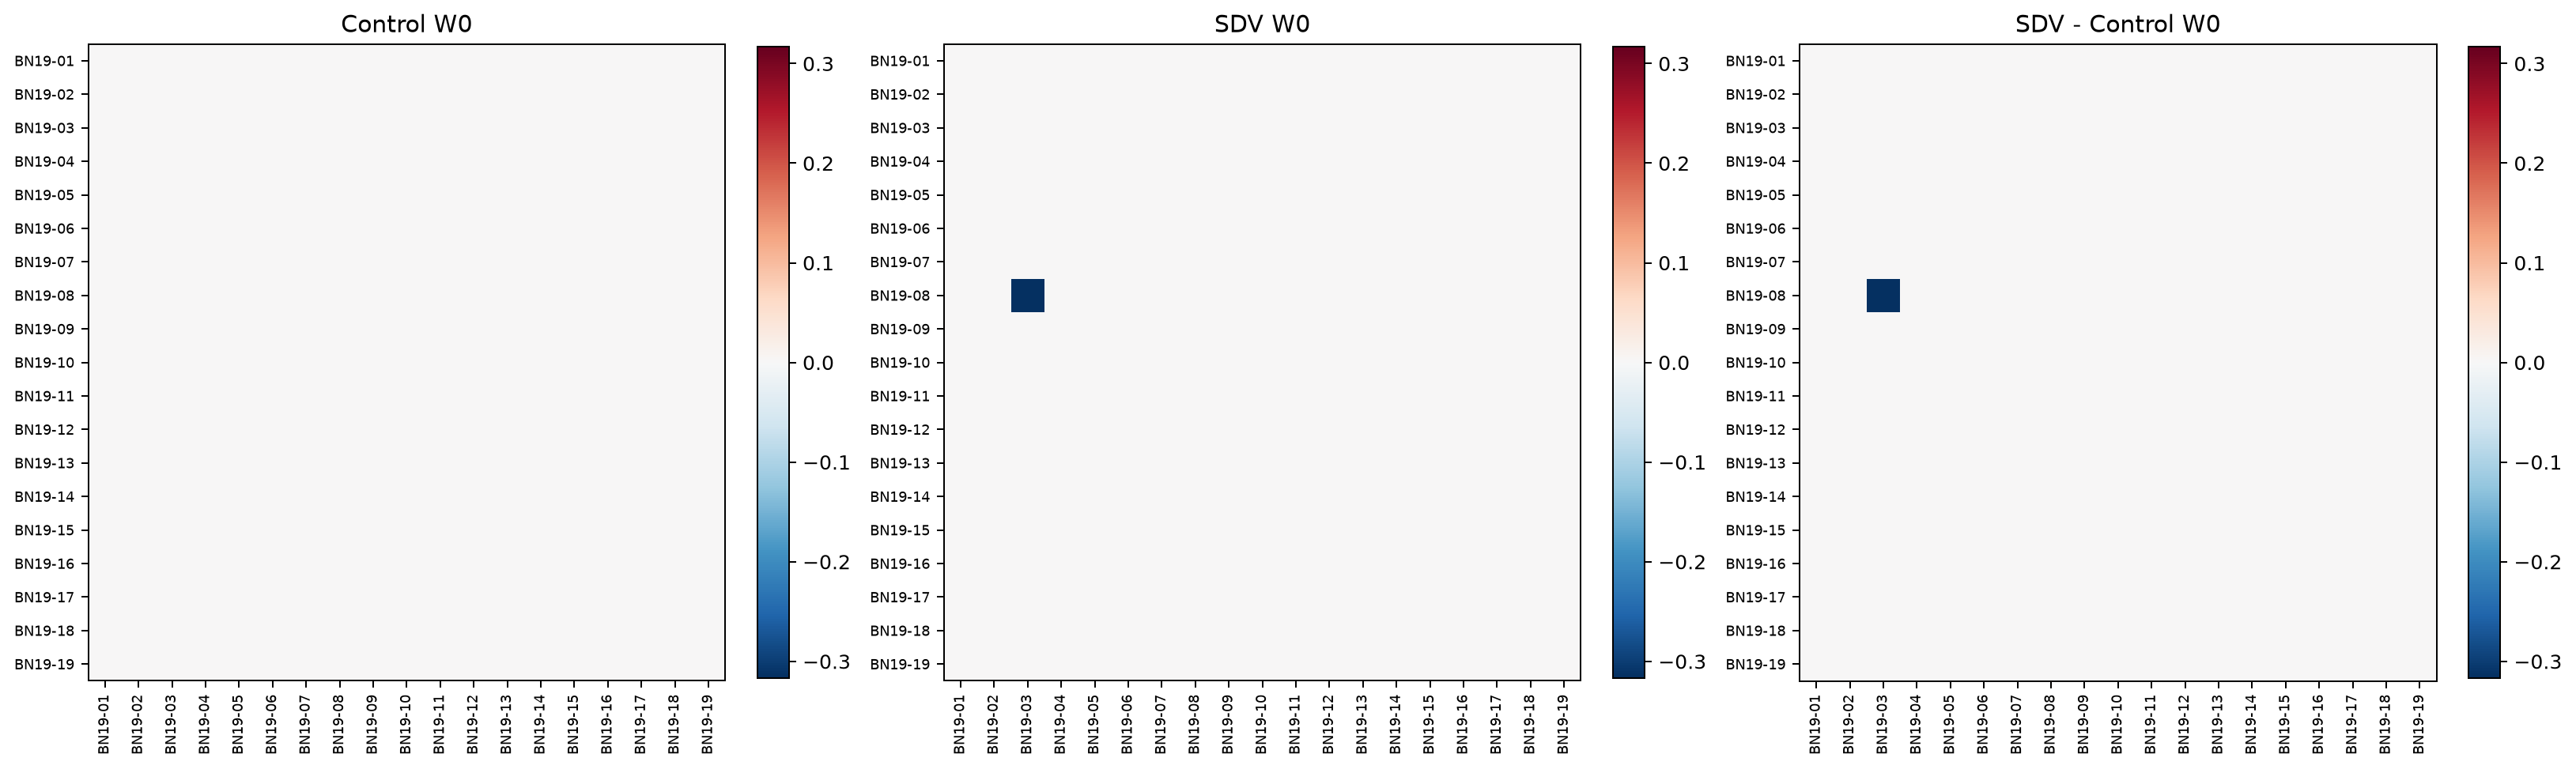

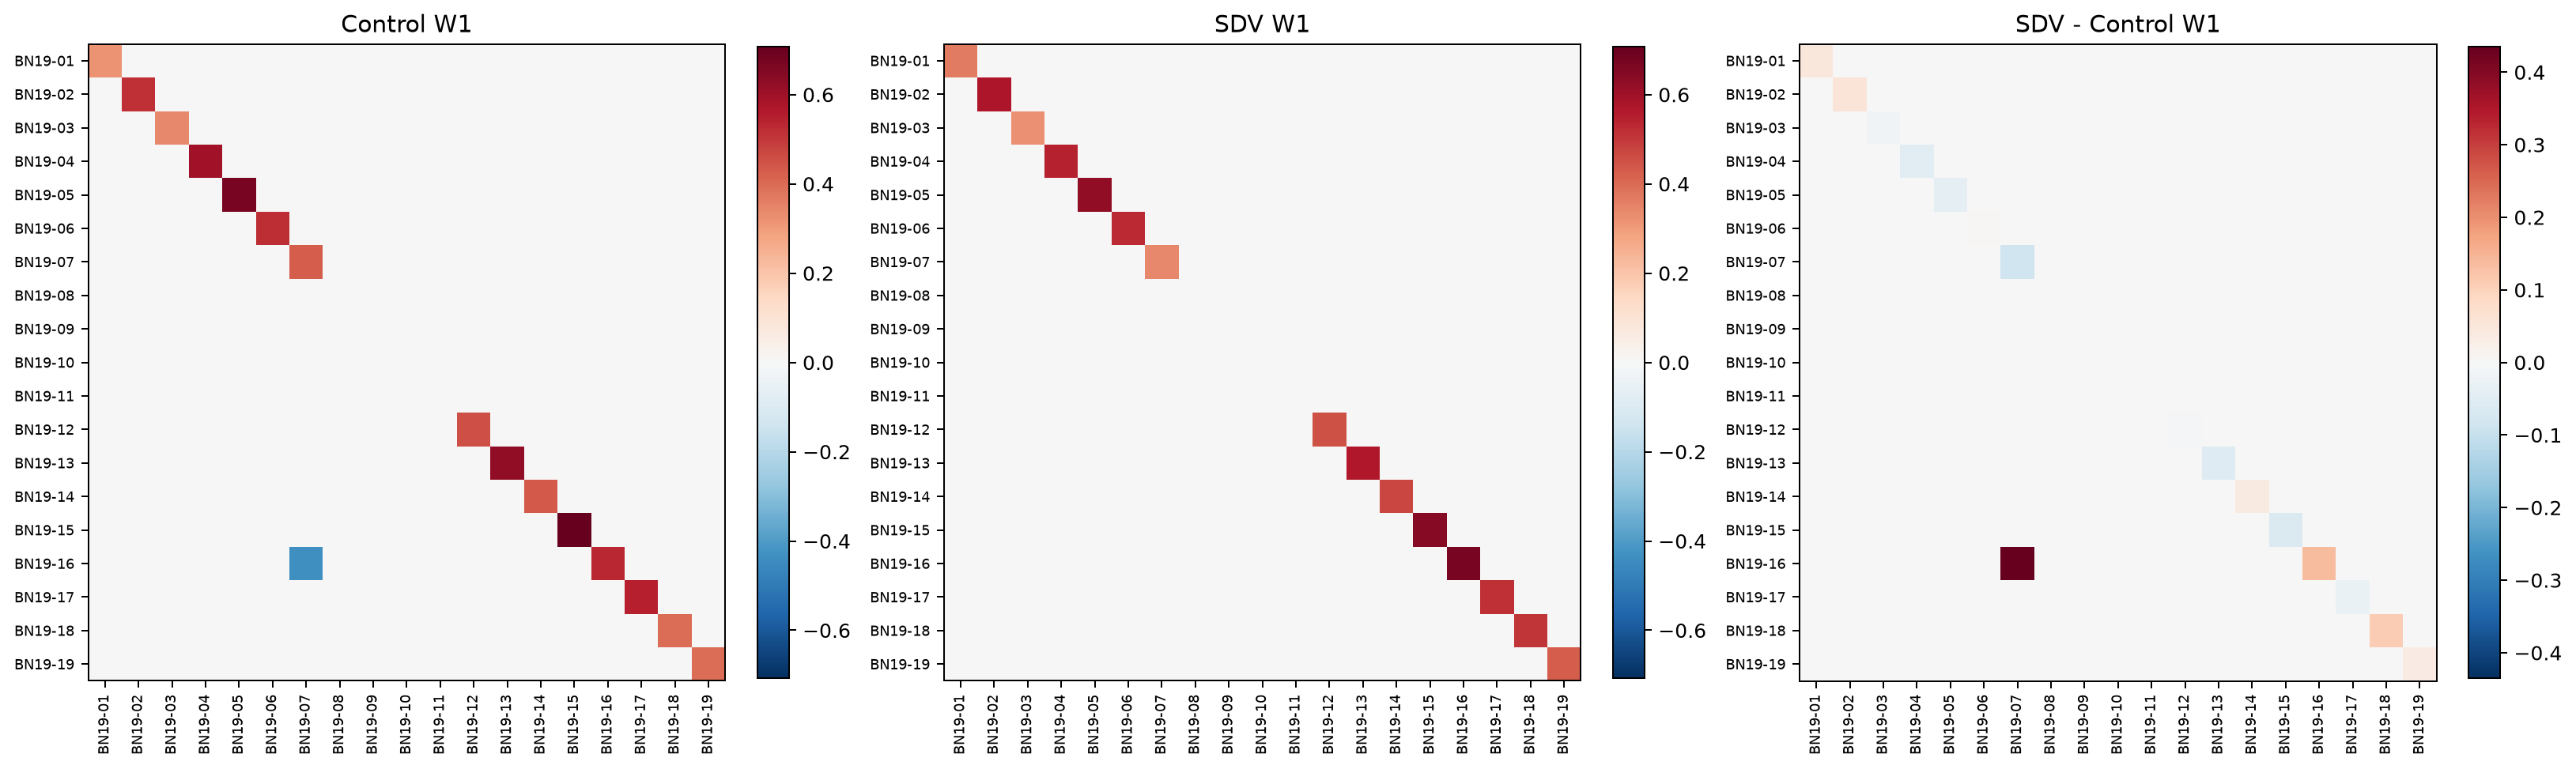

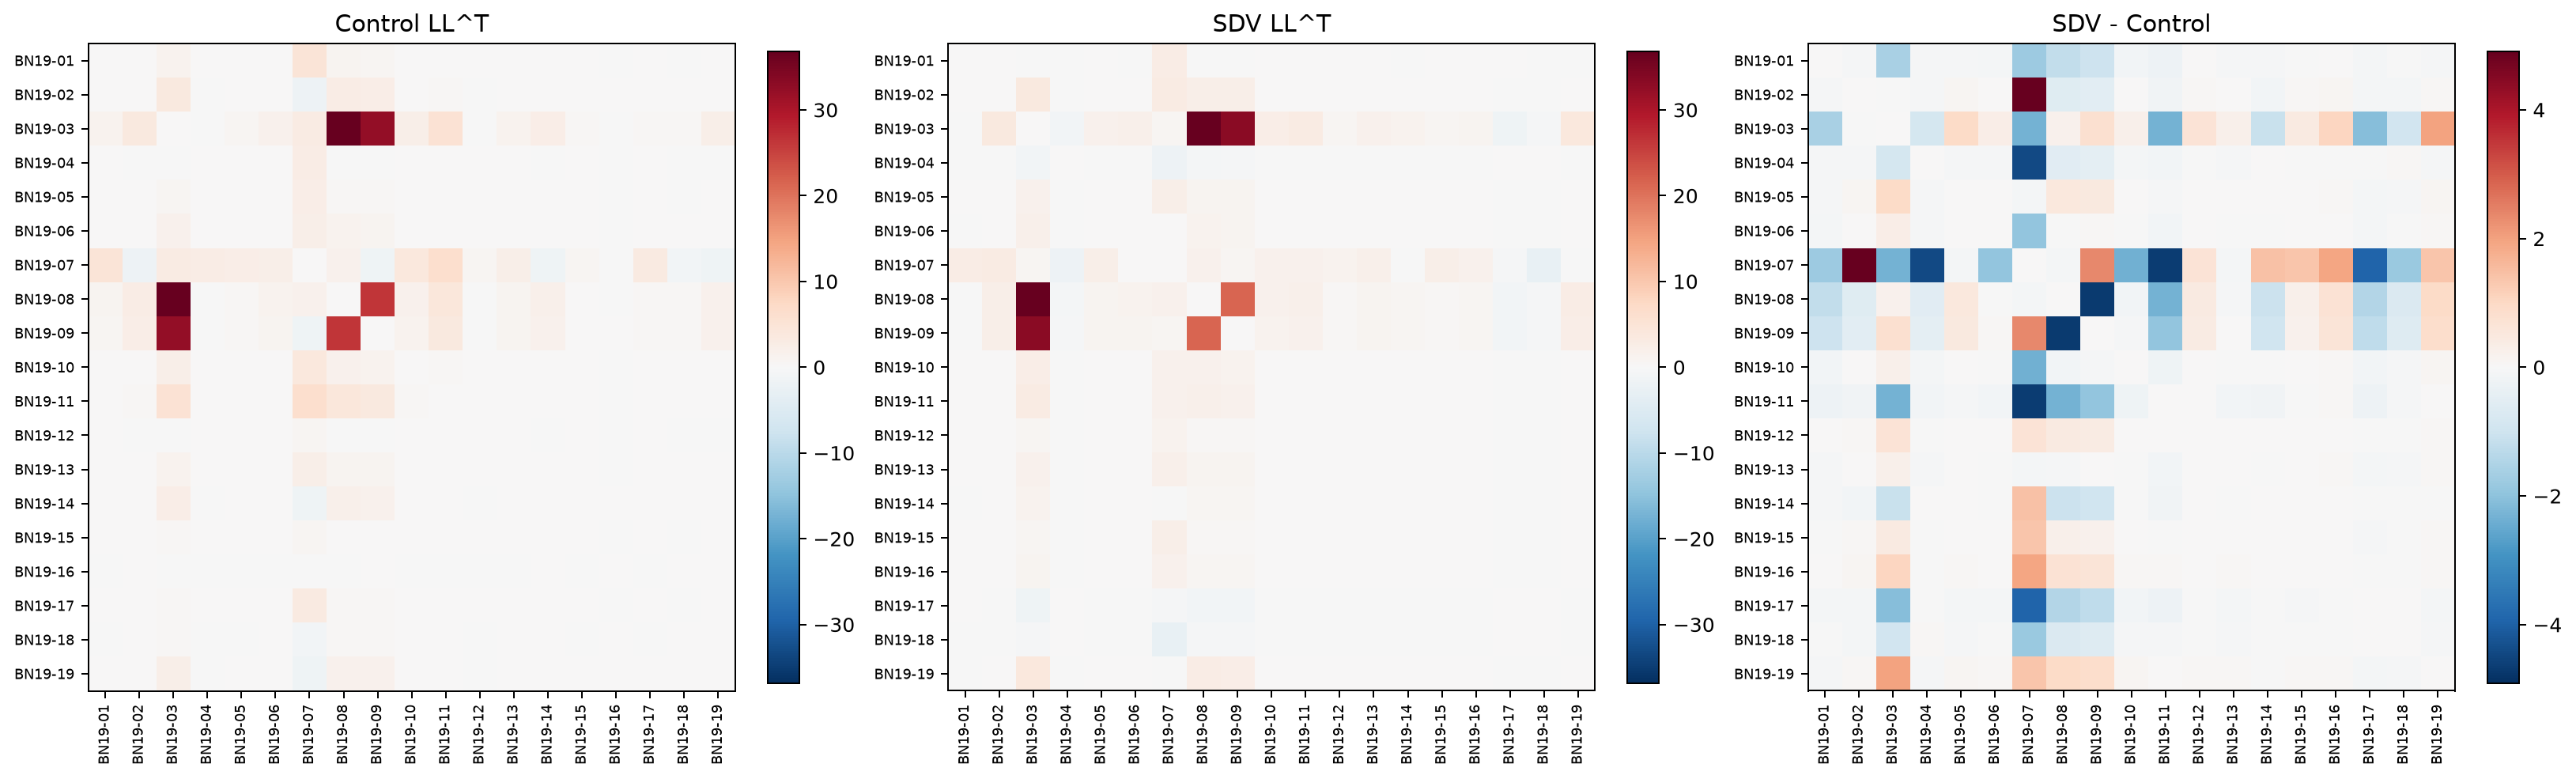

In [8]:
plot_matrix_comparison(dynamic_control.W0,dynamic_sdv.W0,DISPLAY,('Control W0','SDV W0','SDV - Control W0'),OUTPUT/'dynamic_W0_comparison.png')
display(Image(filename=str(OUTPUT/'dynamic_W0_comparison.png')))
for tau in range(P):
    filename=OUTPUT/f'dynamic_Wlag{tau+1}_comparison.png'
    plot_matrix_comparison(dynamic_control.W_lags[tau],dynamic_sdv.W_lags[tau],DISPLAY,(f'Control W{tau+1}',f'SDV W{tau+1}',f'SDV - Control W{tau+1}'),filename)
    display(Image(filename=str(filename)))
DS_control=latent_similarity(dynamic_control); DS_sdv=latent_similarity(dynamic_sdv)
plot_matrix_comparison(DS_control,DS_sdv,DISPLAY,('Control LL^T','SDV LL^T','SDV - Control'),OUTPUT/'dynamic_latent_comparison.png',True)
display(Image(filename=str(OUTPUT/'dynamic_latent_comparison.png')))

## 9. Initial observations
Ranked changes below are descriptive model outputs, not inferential statistics or biological conclusions.

In [9]:
print('Static directed changes:',top_matrix_changes(static_control.W0,static_sdv.W0,DISPLAY))
print('Static latent changes:',top_matrix_changes(S_control,S_sdv,DISPLAY))
print('Dynamic W0 changes:',top_matrix_changes(dynamic_control.W0,dynamic_sdv.W0,DISPLAY))
for tau in range(P): print(f'Lag {tau+1} changes:',top_matrix_changes(dynamic_control.W_lags[tau],dynamic_sdv.W_lags[tau],DISPLAY))

Static directed changes: [{'source': 'BN19-16', 'target': 'BN19-07', 'control': -0.7347268932121247, 'sdv': 0.0, 'change': 0.7347268932121247}, {'source': 'BN19-18', 'target': 'BN19-07', 'control': 0.0, 'sdv': -0.4753200556122066, 'change': -0.4753200556122066}, {'source': 'BN19-11', 'target': 'BN19-07', 'control': 0.43654794241042033, 'sdv': 0.0, 'change': -0.43654794241042033}, {'source': 'BN19-02', 'target': 'BN19-07', 'control': 0.0, 'sdv': 0.3847941438628794, 'change': 0.3847941438628794}, {'source': 'BN19-13', 'target': 'BN19-01', 'control': 0.0, 'sdv': 0.3351937621330644, 'change': 0.3351937621330644}, {'source': 'BN19-06', 'target': 'BN19-13', 'control': 0.3233966920869517, 'sdv': 0.39907821180424463, 'change': 0.07568151971729292}, {'source': 'BN19-06', 'target': 'BN19-12', 'control': 0.4213253638453382, 'sdv': 0.4610018028746211, 'change': 0.03967643902928292}, {'source': 'BN19-12', 'target': 'BN19-13', 'control': 0.5303398629856818, 'sdv': 0.5068297352189386, 'change': -0.02